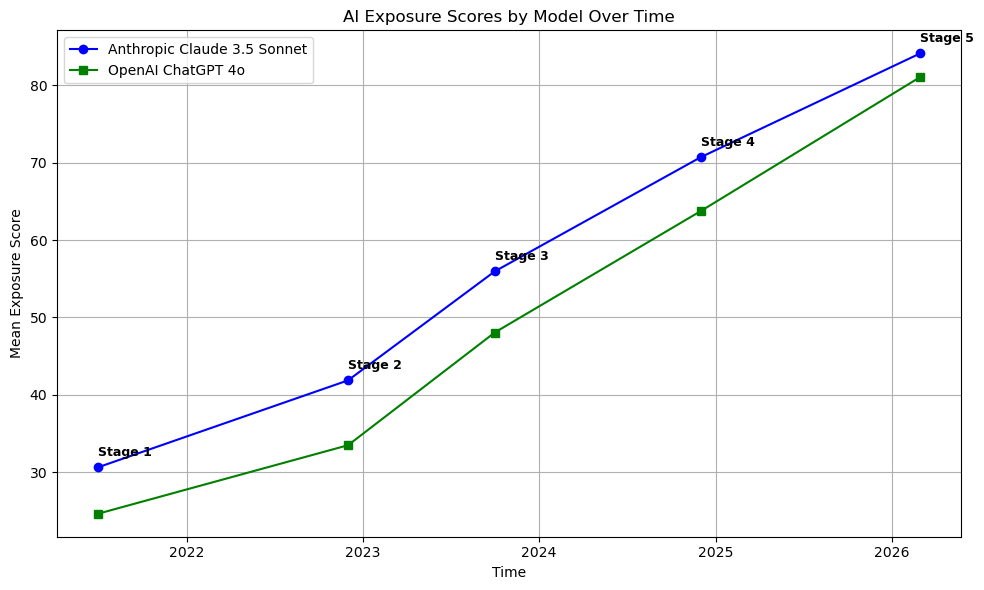

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Create a dictionary to hold mean exposures by stage
stages = {
    'Stage 1': {'date': '2021-07-01', 'openai': 'openai1', 'claude': 'claude1'},
    'Stage 2': {'date': '2022-12-01', 'openai': 'openai2', 'claude': 'claude2'},
    'Stage 3': {'date': '2023-10-01', 'openai': 'openai3', 'claude': 'claude3'},
    'Stage 4': {'date': '2024-12-01', 'openai': 'openai4', 'claude': 'claude4'},
    'Stage 5': {'date': '2026-03-01', 'openai': 'openai5', 'claude': 'claude5'},
}

# Extract average exposure for each stage
stage_data = []
for stage, info in stages.items():
    openai_mean = df[info['openai']].mean()
    claude_mean = df[info['claude']].mean()
    stage_data.append({
        'Stage': stage,
        'Date': pd.to_datetime(info['date']),
        'OpenAI ChatGPT': openai_mean,
        'Anthropic Claude': claude_mean
    })

# Convert to DataFrame and sort
stage_df = pd.DataFrame(stage_data).sort_values('Date')

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(stage_df['Date'], stage_df['Anthropic Claude'], '-o', label='Anthropic Claude 3.5 Sonnet', color='blue')
plt.plot(stage_df['Date'], stage_df['OpenAI ChatGPT'], '-s', label='OpenAI ChatGPT 4o', color='green')

# Annotate each stage
for _, row in stage_df.iterrows():
    plt.text(row['Date'], row['Anthropic Claude'] + 1.5, row['Stage'], fontsize=9, fontweight='bold')

# Labels and formatting
plt.title("AI Exposure Scores by Model Over Time")
plt.xlabel("Time")
plt.ylabel("Mean Exposure Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


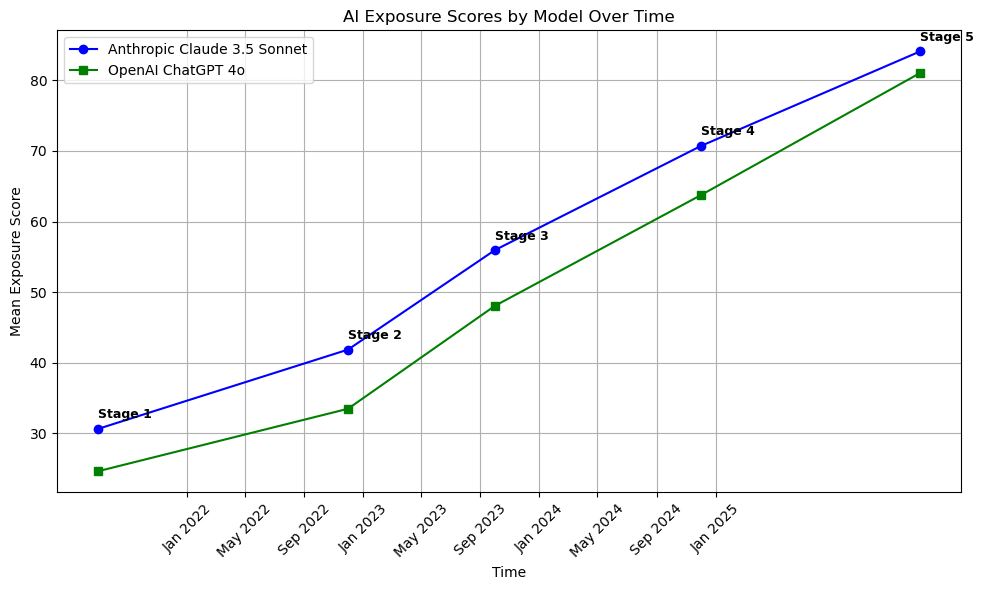

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Load the data
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Define the stage dates and relevant exposure columns
stages = {
    'Stage 1': {'date': '2021-07-01', 'openai': 'openai1', 'claude': 'claude1'},
    'Stage 2': {'date': '2022-12-01', 'openai': 'openai2', 'claude': 'claude2'},
    'Stage 3': {'date': '2023-10-01', 'openai': 'openai3', 'claude': 'claude3'},
    'Stage 4': {'date': '2024-12-01', 'openai': 'openai4', 'claude': 'claude4'},
    'Stage 5': {'date': '2026-03-01', 'openai': 'openai5', 'claude': 'claude5'},
}

# Compute mean exposure values
stage_data = []
for stage, info in stages.items():
    openai_mean = df[info['openai']].mean()
    claude_mean = df[info['claude']].mean()
    stage_data.append({
        'Stage': stage,
        'Date': pd.to_datetime(info['date']),
        'OpenAI ChatGPT': openai_mean,
        'Anthropic Claude': claude_mean
    })

stage_df = pd.DataFrame(stage_data).sort_values('Date')

# Plot
plt.figure(figsize=(10, 6))
plt.plot(stage_df['Date'], stage_df['Anthropic Claude'], '-o', label='Anthropic Claude 3.5 Sonnet', color='blue')
plt.plot(stage_df['Date'], stage_df['OpenAI ChatGPT'], '-s', label='OpenAI ChatGPT 4o', color='green')

# Annotate stage names
for _, row in stage_df.iterrows():
    plt.text(row['Date'], row['Anthropic Claude'] + 1.5, row['Stage'], fontsize=9, fontweight='bold')

# Set custom x-axis ticks every 4 months from Jan 2022 to Jan 2025
tick_dates = pd.date_range(start="2022-01-01", end="2025-01-01", freq="4MS")
plt.xticks(tick_dates, [date.strftime('%b %Y') for date in tick_dates], rotation=45)

# Labels and styling
plt.title("AI Exposure Scores by Model Over Time")
plt.xlabel("Time")
plt.ylabel("Mean Exposure Score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


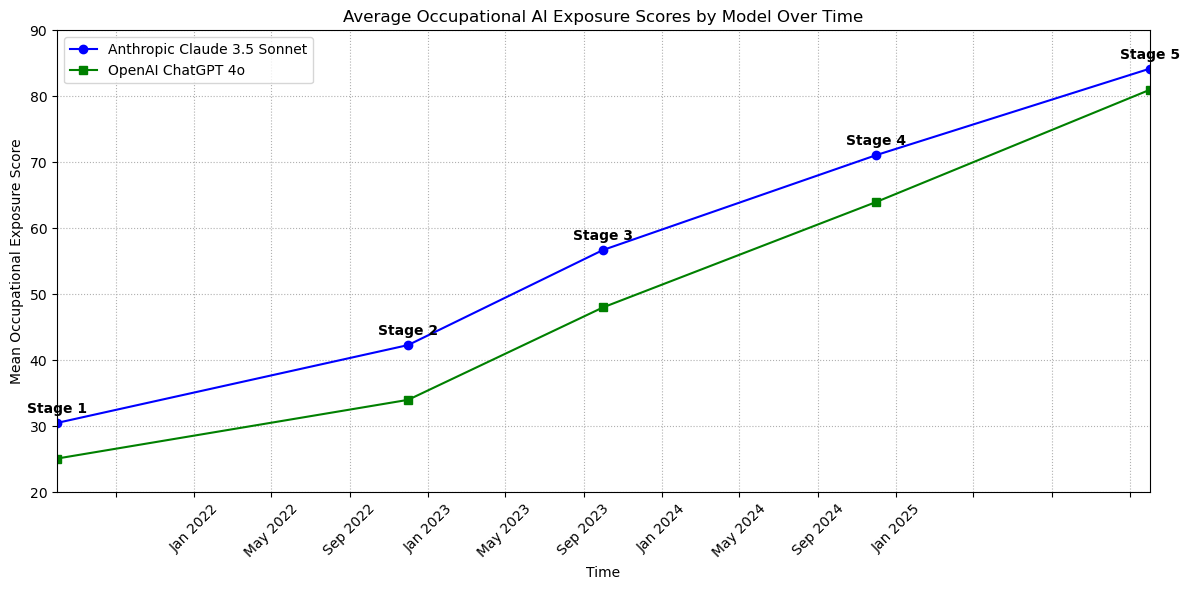

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Create DataFrame with exposure data
df = pd.DataFrame({
    'Date': [
        datetime(2021, 6, 1),  # Stage 1
        datetime(2022, 12, 1), # Stage 2
        datetime(2023, 10, 1), # Stage 3
        datetime(2024, 12, 1), # Stage 4
        datetime(2026, 2, 1)   # Stage 5
    ],
    'Claude': [30.5, 42.3, 56.7, 71.1, 84.2],
    'OpenAI': [25.1, 34.0, 48.0, 64.0, 81.0]
})

# Stage labels
stage_labels = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5']

# Set up plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot lines
ax.plot(df['Date'], df['Claude'], marker='o', label='Anthropic Claude 3.5 Sonnet', color='blue')
ax.plot(df['Date'], df['OpenAI'], marker='s', label='OpenAI ChatGPT 4o', color='green')

# Annotate stage labels above Claude line
for i, label in enumerate(stage_labels):
    ax.text(df['Date'][i], df['Claude'][i] + 1.5, label, fontsize=10, weight='bold', ha='center')

# Generate x-ticks every 4 months from Jun 2021 to Feb 2026
all_xticks = pd.date_range(start='2021-01-01', end='2026-02-01', freq='4MS')


# Define range for visible labels
label_start = datetime(2022, 1, 1)
label_end = datetime(2025, 3, 1)

# Set xticks and selectively assign labels
xtick_labels = [
    date.strftime('%b %Y') if label_start <= date <= label_end else ''
    for date in all_xticks
]

ax.set_xticks(all_xticks)
ax.set_xticklabels(xtick_labels, rotation=45)

# Set x and y limits
ax.set_xlim([datetime(2021, 6, 1), datetime(2026, 2, 1)])
ax.set_ylim(20, 90)

# Add dotted grid lines for x and y axes
ax.grid(True, which='both', linestyle=':', linewidth=0.8, axis='both')

# Labels and title
ax.set_ylabel('Mean Occupational Exposure Score')
ax.set_xlabel('Time')
ax.set_title('Average Occupational AI Exposure Scores by Model Over Time')
ax.legend()

plt.tight_layout()
plt.savefig("Output/May/desc/exp_v_time.png", dpi=300, bbox_inches='tight')
plt.show()




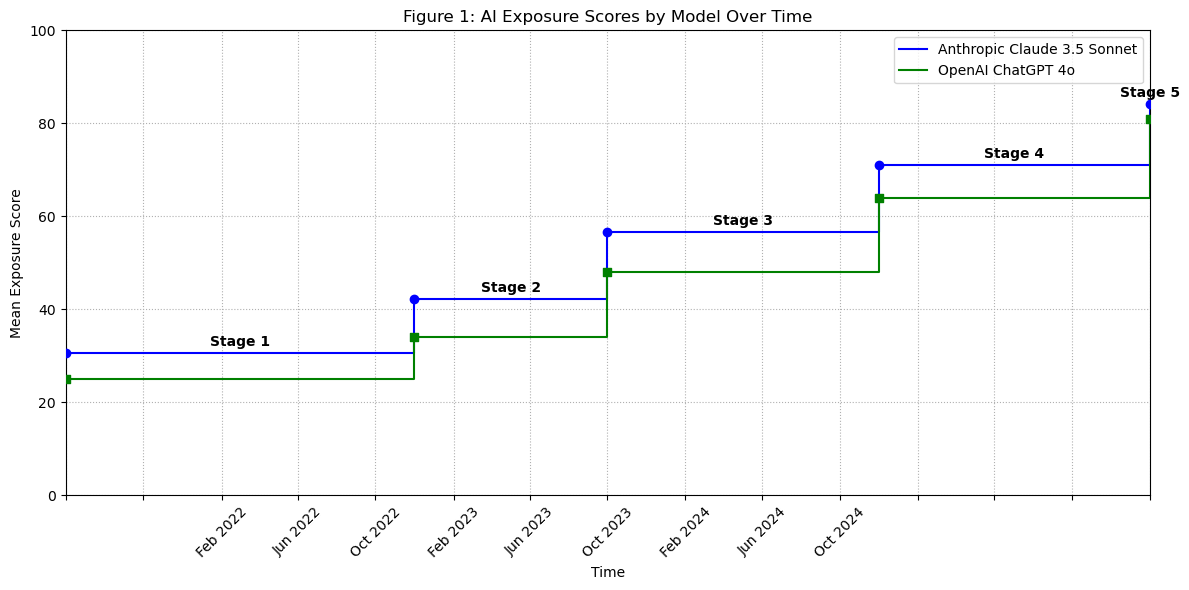

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Create DataFrame with exposure data
df = pd.DataFrame({
    'Date': [
        datetime(2021, 6, 1),  # Stage 1
        datetime(2022, 12, 1), # Stage 2
        datetime(2023, 10, 1), # Stage 3
        datetime(2024, 12, 1), # Stage 4
        datetime(2026, 2, 1)   # Stage 5
    ],
    'Claude': [30.5, 42.3, 56.7, 71.1, 84.2],
    'OpenAI': [25.1, 34.0, 48.0, 64.0, 81.0]
})

# Step data: extend each exposure value to next date
step_dates = []
step_claude = []
step_openai = []

for i in range(len(df) - 1):
    # Hold value constant until next stage
    step_dates += [df['Date'][i], df['Date'][i+1]]
    step_claude += [df['Claude'][i]] * 2
    step_openai += [df['OpenAI'][i]] * 2

# Final segment
step_dates.append(df['Date'].iloc[-1])
step_claude.append(df['Claude'].iloc[-1])
step_openai.append(df['OpenAI'].iloc[-1])

# Stage labels
stage_labels = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5']

# Set up plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot step lines
ax.plot(step_dates, step_claude, drawstyle='steps-post', label='Anthropic Claude 3.5 Sonnet', color='blue')
ax.plot(step_dates, step_openai, drawstyle='steps-post', label='OpenAI ChatGPT 4o', color='green')

ax.scatter(df['Date'], df['Claude'], color='blue', marker='o', zorder=5)
ax.scatter(df['Date'], df['OpenAI'], color='green', marker='s', zorder=5)


# Annotate stage labels above Claude line at the midpoint of each stage
for i in range(len(df) - 1):
    mid_date = df['Date'][i] + (df['Date'][i+1] - df['Date'][i]) / 2
    ax.text(mid_date, df['Claude'][i] + 1.5, stage_labels[i], fontsize=10, weight='bold', ha='center')
# Add final stage label
ax.text(df['Date'].iloc[-1], df['Claude'].iloc[-1] + 1.5, stage_labels[-1], fontsize=10, weight='bold', ha='center')

# Generate x-ticks every 4 months from Jun 2021 to Feb 2026
all_xticks = pd.date_range(start='2021-06-01', end='2026-02-01', freq='4MS')

# Define label range (Jan 2022 to Jan 2025)
label_start = datetime(2022, 1, 1)
label_end = datetime(2025, 1, 1)

xtick_labels = [
    date.strftime('%b %Y') if label_start <= date <= label_end else ''
    for date in all_xticks
]

ax.set_xticks(all_xticks)
ax.set_xticklabels(xtick_labels, rotation=45)

# Set limits
ax.set_xlim([datetime(2021, 6, 1), datetime(2026, 2, 1)])
ax.set_ylim(0, 100)

# Dotted grid lines
ax.grid(True, which='both', linestyle=':', linewidth=0.8, axis='both')

# Labels and title
ax.set_ylabel('Mean Exposure Score')
ax.set_xlabel('Time')
ax.set_title('Figure 1: AI Exposure Scores by Model Over Time')
ax.legend()

plt.tight_layout()
plt.savefig("Output/Draft_5_20/III_Data/exp_v_time_stepped.png", dpi=300, bbox_inches='tight')
plt.show()


/var/folders/pw/rvl88q8j7599v3sdt405cx1w0000gq/T/ipykernel_24512/248271610.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["broad_soc"] = df[soc_column].astype(str).str[:2]
/var/folders/pw/rvl88q8j7599v3sdt405cx1w0000gq/T/ipykernel_24512/248271610.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["occupation_group"] = df["broad_soc"].map(soc_mapping)
/var/folders/pw/rvl88q8j7599v3sdt405cx1w0000gq/T/ipykernel_24512/248271610.py:56: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of ca

<Figure size 1200x600 with 0 Axes>

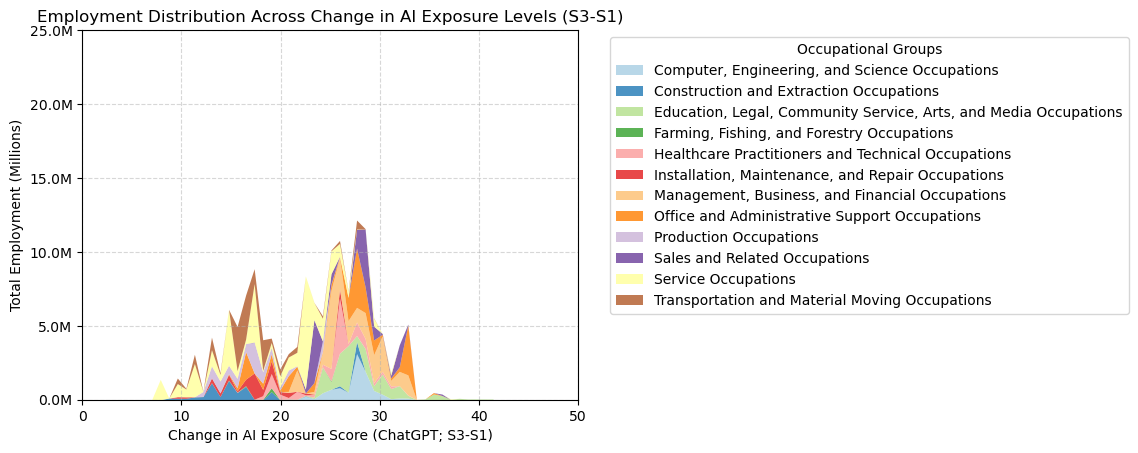

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
file_path = "/Users/jdomins2/Desktop/CPS_Work/Data/Working/AA_oews_SOC_educ.dta"
df = pd.read_stata(file_path)

# Define AI exposure column and employment column
exposure_column = "d_openai_S3_S1"  # Update this based on the stage you're visualizing
employment_column = "tot_emp_24"
soc_column = "soc_code"  # Column that stores SOC codes

# Extract the first two digits of SOC codes to assign broad occupational groups
df["broad_soc"] = df[soc_column].astype(str).str[:2]


# Define SOC broad group mapping (Intermediate Aggregation)
soc_mapping = {
    "11": "Management, Business, and Financial Occupations",
    "13": "Management, Business, and Financial Occupations",
    "15": "Computer, Engineering, and Science Occupations",
    "17": "Computer, Engineering, and Science Occupations",
    "19": "Computer, Engineering, and Science Occupations",
    "21": "Education, Legal, Community Service, Arts, and Media Occupations",
    "23": "Education, Legal, Community Service, Arts, and Media Occupations",
    "25": "Education, Legal, Community Service, Arts, and Media Occupations",
    "27": "Education, Legal, Community Service, Arts, and Media Occupations",
    "29": "Healthcare Practitioners and Technical Occupations",
    "31": "Service Occupations",
    "33": "Service Occupations",
    "35": "Service Occupations",
    "37": "Service Occupations",
    "39": "Service Occupations",
    "41": "Sales and Related Occupations",
    "43": "Office and Administrative Support Occupations",
    "45": "Farming, Fishing, and Forestry Occupations",
    "47": "Construction and Extraction Occupations",
    "49": "Installation, Maintenance, and Repair Occupations",
    "51": "Production Occupations",
    "53": "Transportation and Material Moving Occupations"
}

# Apply mapping
df["occupation_group"] = df["broad_soc"].map(soc_mapping)


# Map broad SOC groups to their corresponding names
df["occupation_group"] = df["broad_soc"].map(soc_mapping)

# Drop missing values in key columns
df = df.dropna(subset=[exposure_column, employment_column, "occupation_group"])

# Bin exposure scores into fixed intervals (ensuring numerical bins)
bins = np.linspace(7, 44, 44)  # ~1 bin per 1 unit of change
df["exposure_bin"] = pd.cut(df[exposure_column], bins, labels=bins[:-1], include_lowest=True)

# Aggregate employment by exposure bin and occupation group
employment_distribution = df.groupby(["exposure_bin", "occupation_group"], observed=True)[employment_column].sum().unstack()

# Ensure the bins are numeric for proper sorting
employment_distribution.index = employment_distribution.index.astype(float)

import matplotlib.ticker as mticker

# Create figure
plt.figure(figsize=(12, 6))

# Plot
employment_distribution.sort_index().plot(kind="area", stacked=True, colormap="Paired", alpha=0.8, linewidth=0)

# Formatting the plot
plt.xlabel("Change in AI Exposure Score (ChatGPT; S3-S1)")
plt.ylabel("Total Employment (Millions)")
plt.title("Employment Distribution Across Change in AI Exposure Levels (S3-S1)")
plt.legend(title="Occupational Groups", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(0, 50)
plt.ylim(0, 25e6)

# Convert y-axis labels from scientific notation to millions
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M'))

# Save and show the figure
plt.savefig("/Users/jdomins2/Desktop/CPS_Work/Output/May/desc/exp_emp_3_1_test.png", dpi=300, bbox_inches="tight")
plt.show()


<Figure size 1200x600 with 0 Axes>

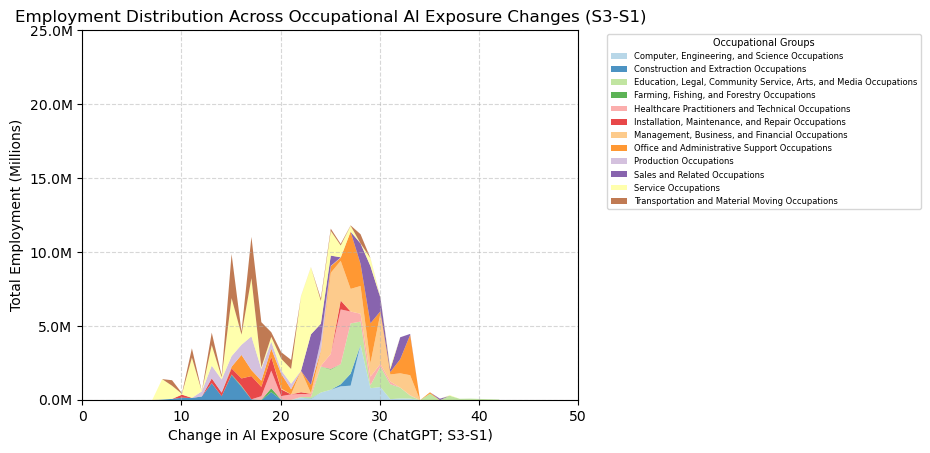

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
file_path = "/Users/jdomins2/Desktop/CPS_Work/Data/Cleaned/oews_exp_24.dta"
df = pd.read_stata(file_path)

# Define AI exposure column and employment column
exposure_column = "d_openai_3_1"  # Update this based on the stage you're visualizing
employment_column = "TOT_EMP"
soc_column = "soc_code"  # Column that stores SOC codes

# Extract the first two digits of SOC codes to assign broad occupational groups
df["broad_soc"] = df[soc_column].astype(str).str[:2]


# Define SOC broad group mapping (Intermediate Aggregation)
soc_mapping = {
    "11": "Management, Business, and Financial Occupations",
    "13": "Management, Business, and Financial Occupations",
    "15": "Computer, Engineering, and Science Occupations",
    "17": "Computer, Engineering, and Science Occupations",
    "19": "Computer, Engineering, and Science Occupations",
    "21": "Education, Legal, Community Service, Arts, and Media Occupations",
    "23": "Education, Legal, Community Service, Arts, and Media Occupations",
    "25": "Education, Legal, Community Service, Arts, and Media Occupations",
    "27": "Education, Legal, Community Service, Arts, and Media Occupations",
    "29": "Healthcare Practitioners and Technical Occupations",
    "31": "Service Occupations",
    "33": "Service Occupations",
    "35": "Service Occupations",
    "37": "Service Occupations",
    "39": "Service Occupations",
    "41": "Sales and Related Occupations",
    "43": "Office and Administrative Support Occupations",
    "45": "Farming, Fishing, and Forestry Occupations",
    "47": "Construction and Extraction Occupations",
    "49": "Installation, Maintenance, and Repair Occupations",
    "51": "Production Occupations",
    "53": "Transportation and Material Moving Occupations"
}

# Apply mapping
df["occupation_group"] = df["broad_soc"].map(soc_mapping)


# Map broad SOC groups to their corresponding names
df["occupation_group"] = df["broad_soc"].map(soc_mapping)

# Drop missing values in key columns
df = df.dropna(subset=[exposure_column, employment_column, "occupation_group"])

# Bin exposure scores into fixed intervals (ensuring numerical bins)
bins = np.arange(7, 44, 1)  # ~1 bin per 1 unit of change
df["exposure_bin"] = pd.cut(df[exposure_column], bins, labels=bins[:-1], include_lowest=True)

# Aggregate employment by exposure bin and occupation group
employment_distribution = df.groupby(["exposure_bin", "occupation_group"], observed=True)[employment_column].sum().unstack()

# Ensure the bins are numeric for proper sorting
employment_distribution.index = employment_distribution.index.astype(float)

import matplotlib.ticker as mticker

# Create figure
plt.figure(figsize=(12, 6))

# Plot
employment_distribution.sort_index().plot(kind="area", stacked=True, colormap="Paired", alpha=0.8, linewidth=0)

# Formatting the plot
plt.xlabel("Change in AI Exposure Score (ChatGPT; S3-S1)")
plt.ylabel("Total Employment (Millions)")
plt.title("Employment Distribution Across Occupational AI Exposure Changes (S3-S1)")
plt.legend(title="Occupational Groups", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=6, title_fontsize=7)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(0, 50)
plt.ylim(0, 25e6)

# Convert y-axis labels from scientific notation to millions
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M'))

# Save and show the figure
plt.savefig("/Users/jdomins2/Desktop/CPS_Work/Output/May/desc/exp_emp_3_1.png", dpi=300, bbox_inches="tight")
plt.show()


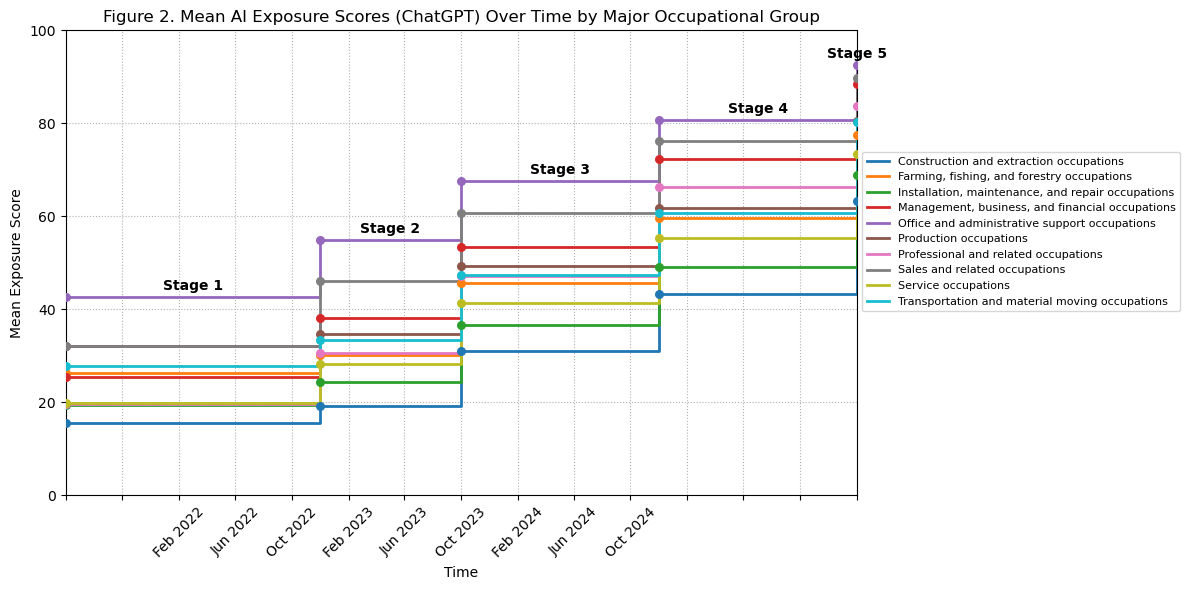

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Load the data
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Define group mapping (Census occupation code ranges)
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

# Assign groups
def assign_group(code):
    for group, code_range in group_map.items():
        if code in code_range:
            return group
    return 'Unclassified'

df['group'] = df['cps_code'].apply(assign_group)

# Compute mean scores by group and stage
stage_cols = ['openai1', 'openai2', 'openai3', 'openai4', 'openai5']
mean_by_group = df.groupby('group')[stage_cols].mean().reset_index()

# Dates for stages
stage_dates = [
    datetime(2021, 6, 1),  # Stage 1
    datetime(2022, 12, 1), # Stage 2
    datetime(2023, 10, 1), # Stage 3
    datetime(2024, 12, 1), # Stage 4
    datetime(2026, 2, 1)   # Stage 5
]

stage_labels = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5']

# Set up plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each group's step line + dots
colors = plt.cm.tab10.colors
for idx, row in mean_by_group.iterrows():
    label = row['group']
    values = [row[col] for col in stage_cols]

    step_dates = []
    step_vals = []
    for i in range(len(values) - 1):
        step_dates += [stage_dates[i], stage_dates[i+1]]
        step_vals += [values[i]] * 2
    step_dates.append(stage_dates[-1])
    step_vals.append(values[-1])

    ax.plot(step_dates, step_vals, drawstyle='steps-post', label=label, linewidth=2)
    ax.scatter(stage_dates, values, s=30, zorder=5)  # dots at each stage

# Annotate stage labels above the max group mean for each stage
for i in range(len(stage_dates) - 1):
    mid = stage_dates[i] + (stage_dates[i+1] - stage_dates[i]) / 2
    max_val = mean_by_group[stage_cols[i]].max()
    ax.text(mid, max_val + 1.5, stage_labels[i], fontsize=10, weight='bold', ha='center')
# Final label at Stage 5
max_val_final = mean_by_group[stage_cols[-1]].max()
ax.text(stage_dates[-1], max_val_final + 1.5, stage_labels[-1], fontsize=10, weight='bold', ha='center')

# X-ticks every 4 months with selected label range
all_xticks = pd.date_range(start='2021-06-01', end='2026-02-01', freq='4MS')
label_start = datetime(2022, 1, 1)
label_end = datetime(2025, 1, 1)
xtick_labels = [
    dt.strftime('%b %Y') if label_start <= dt <= label_end else '' for dt in all_xticks
]
ax.set_xticks(all_xticks)
ax.set_xticklabels(xtick_labels, rotation=45)

# Set limits
ax.set_xlim([datetime(2021, 6, 1), datetime(2026, 2, 1)])
ax.set_ylim(0, 100)

# Grid and labels
ax.grid(True, which='both', linestyle=':', linewidth=0.8)
ax.set_ylabel('Mean Exposure Score')
ax.set_xlabel('Time')
ax.set_title('Figure 2. Mean AI Exposure Scores (ChatGPT) Over Time by Major Occupational Group')

# Legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 0.75), fontsize=8)
plt.tight_layout()
plt.savefig("Output/Draft_5_20/III_Data/exp_by_occgroup_chatgpt_stepped.png", dpi=300, bbox_inches='tight')
plt.show()


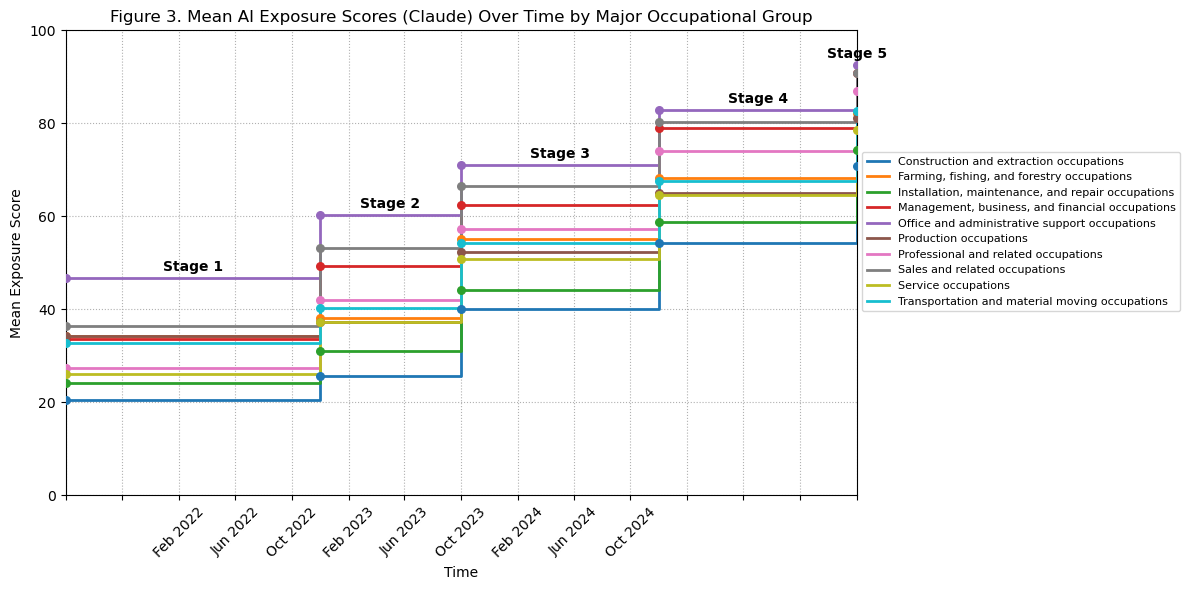

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Load the data
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Define group mapping (Census occupation code ranges)
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

# Assign groups
def assign_group(code):
    for group, code_range in group_map.items():
        if code in code_range:
            return group
    return 'Unclassified'

df['group'] = df['cps_code'].apply(assign_group)

# Compute mean scores by group and stage
stage_cols = ['claude1', 'claude2', 'claude3', 'claude4', 'claude5']
mean_by_group = df.groupby('group')[stage_cols].mean().reset_index()

# Dates for stages
stage_dates = [
    datetime(2021, 6, 1),  # Stage 1
    datetime(2022, 12, 1), # Stage 2
    datetime(2023, 10, 1), # Stage 3
    datetime(2024, 12, 1), # Stage 4
    datetime(2026, 2, 1)   # Stage 5
]

stage_labels = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5']

# Set up plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each group's step line + dots
colors = plt.cm.tab10.colors
for idx, row in mean_by_group.iterrows():
    label = row['group']
    values = [row[col] for col in stage_cols]

    step_dates = []
    step_vals = []
    for i in range(len(values) - 1):
        step_dates += [stage_dates[i], stage_dates[i+1]]
        step_vals += [values[i]] * 2
    step_dates.append(stage_dates[-1])
    step_vals.append(values[-1])

    ax.plot(step_dates, step_vals, drawstyle='steps-post', label=label, linewidth=2)
    ax.scatter(stage_dates, values, s=30, zorder=5)  # dots at each stage

# Annotate stage labels above the max group mean for each stage
for i in range(len(stage_dates) - 1):
    mid = stage_dates[i] + (stage_dates[i+1] - stage_dates[i]) / 2
    max_val = mean_by_group[stage_cols[i]].max()
    ax.text(mid, max_val + 1.5, stage_labels[i], fontsize=10, weight='bold', ha='center')
# Final label at Stage 5
max_val_final = mean_by_group[stage_cols[-1]].max()
ax.text(stage_dates[-1], max_val_final + 1.5, stage_labels[-1], fontsize=10, weight='bold', ha='center')

# X-ticks every 4 months with selected label range
all_xticks = pd.date_range(start='2021-06-01', end='2026-02-01', freq='4MS')
label_start = datetime(2022, 1, 1)
label_end = datetime(2025, 1, 1)
xtick_labels = [
    dt.strftime('%b %Y') if label_start <= dt <= label_end else '' for dt in all_xticks
]
ax.set_xticks(all_xticks)
ax.set_xticklabels(xtick_labels, rotation=45)

# Set limits
ax.set_xlim([datetime(2021, 6, 1), datetime(2026, 2, 1)])
ax.set_ylim(0, 100)

# Grid and labels
ax.grid(True, which='both', linestyle=':', linewidth=0.8)
ax.set_ylabel('Mean Exposure Score')
ax.set_xlabel('Time')
ax.set_title('Figure 3. Mean AI Exposure Scores (Claude) Over Time by Major Occupational Group')

# Legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 0.75), fontsize=8)
plt.tight_layout()
plt.savefig("Output/Draft_5_20/III_Data/exp_by_occgroup_claude_stepped.png", dpi=300, bbox_inches='tight')
plt.show()


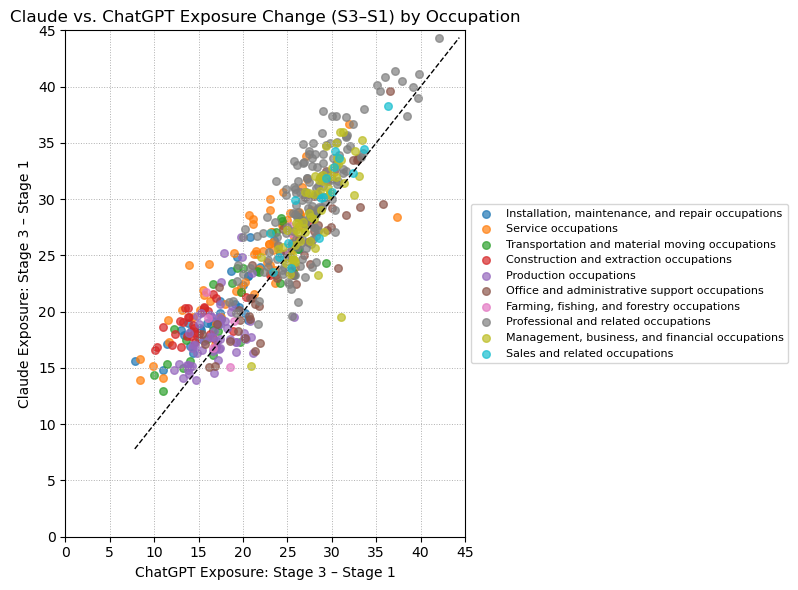

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Define group mapping based on CPS occupation codes
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

# Determine global min and max across all relevant OpenAI and Claude variables
exposure_columns = ['openai1', 'openai2', 'openai3', 'openai4', 'openai5',
                    'claude1', 'claude2', 'claude3', 'claude4', 'claude5',
                    'd_openai_S3_S1', 'd_claude_S3_S1', 'd_openai_S3_S2',
                    'd_claude_S3_S2', 'd_openai_S2_S1', 'd_claude_S2_S1']

# Get global min/max across all
global_min = df[exposure_columns].min().min()
global_max = df[exposure_columns].max().max()

# Optionally pad the limits a bit for nicer plotting
buffer = 2
global_lims = [global_min - buffer, global_max + buffer]


# Assign group label
def assign_group(code):
    for group, code_range in group_map.items():
        if code in code_range:
            return group
    return 'Unclassified'

df['group'] = df['cps_code'].apply(assign_group)

# Subset needed variables
df['openai_delta'] = df['d_openai_S3_S1']
df['claude_delta'] = df['d_claude_S3_S1']

# Set up plot
fig, ax = plt.subplots(figsize=(8, 6))

# Assign colors for groups
group_colors = {
    group: color for group, color in zip(df['group'].unique(), plt.cm.tab10.colors)
}

# Plot by group
for group, color in group_colors.items():
    sub = df[df['group'] == group]
    ax.scatter(
        sub['openai_delta'], sub['claude_delta'],
        label=group, alpha=0.7, s=30, color=color
    )

# Add 45-degree line
lims = [
    np.min([df['openai_delta'].min(), df['claude_delta'].min()]),
    np.max([df['openai_delta'].max(), df['claude_delta'].max()])
]
ax.plot(lims, lims, 'k--', linewidth=1)

# Axis labels and title
ax.set_xlabel("ChatGPT Exposure: Stage 3 – Stage 1")
ax.set_ylabel("Claude Exposure: Stage 3 – Stage 1")
ax.set_title("Claude vs. ChatGPT Exposure Change (S3–S1) by Occupation")

# Format and legend
ax.grid(True, linestyle=':', linewidth=0.7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

# Set consistent axis limits
ax.set_xlim(0,45)
ax.set_ylim(0,45)

plt.tight_layout()
plt.savefig("Output/Draft_5_20/III_Data/3_1_scatter_by_group.png", dpi=300, bbox_inches='tight')
plt.show()


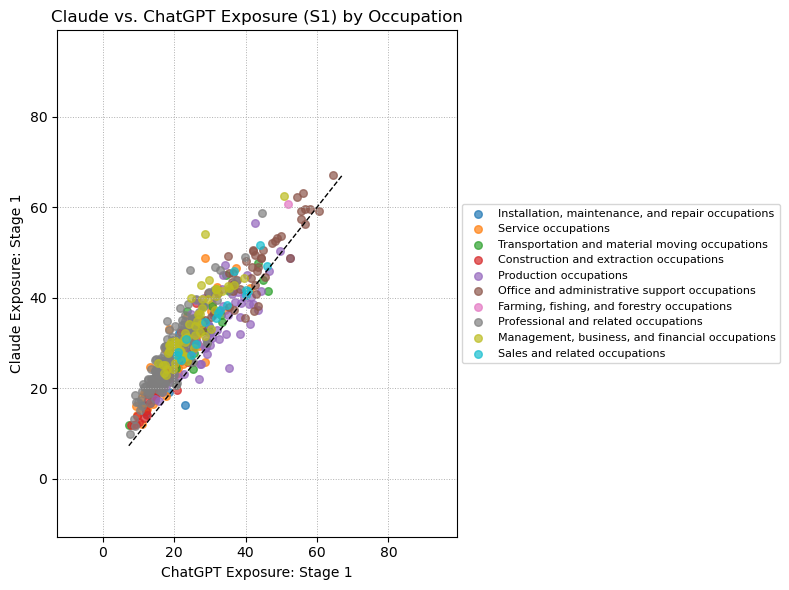

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Define group mapping based on CPS occupation codes
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

# Determine global min and max across all relevant OpenAI and Claude variables
exposure_columns = ['openai1', 'openai2', 'openai3', 'openai4', 'openai5',
                    'claude1', 'claude2', 'claude3', 'claude4', 'claude5',
                    'd_openai_S3_S1', 'd_claude_S3_S1', 'd_openai_S3_S2',
                    'd_claude_S3_S2', 'd_openai_S2_S1', 'd_claude_S2_S1']

# Get global min/max across all
global_min = df[exposure_columns].min().min()
global_max = df[exposure_columns].max().max()

# Optionally pad the limits a bit for nicer plotting
buffer = 2
global_lims = [global_min - buffer, global_max + buffer]

# Assign group label
def assign_group(code):
    for group, code_range in group_map.items():
        if code in code_range:
            return group
    return 'Unclassified'

df['group'] = df['cps_code'].apply(assign_group)

# Subset needed variables
df['openai_delta'] = df['openai1']
df['claude_delta'] = df['claude1']

# Set up plot
fig, ax = plt.subplots(figsize=(8, 6))

# Assign colors for groups
group_colors = {
    group: color for group, color in zip(df['group'].unique(), plt.cm.tab10.colors)
}

# Plot by group
for group, color in group_colors.items():
    sub = df[df['group'] == group]
    ax.scatter(
        sub['openai_delta'], sub['claude_delta'],
        label=group, alpha=0.7, s=30, color=color
    )

# Add 45-degree line
lims = [
    np.min([df['openai_delta'].min(), df['claude_delta'].min()]),
    np.max([df['openai_delta'].max(), df['claude_delta'].max()])
]
ax.plot(lims, lims, 'k--', linewidth=1)

# Axis labels and title
ax.set_xlabel("ChatGPT Exposure: Stage 1")
ax.set_ylabel("Claude Exposure: Stage 1")
ax.set_title("Claude vs. ChatGPT Exposure (S1) by Occupation")

# Format and legend
ax.grid(True, linestyle=':', linewidth=0.7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)


# Set consistent axis limits
ax.set_xlim(global_lims)
ax.set_ylim(global_lims)

plt.tight_layout()
plt.savefig("Output/Draft_5_20/III_Data/S1_scatter_by_group.png", dpi=300, bbox_inches='tight')
plt.show()


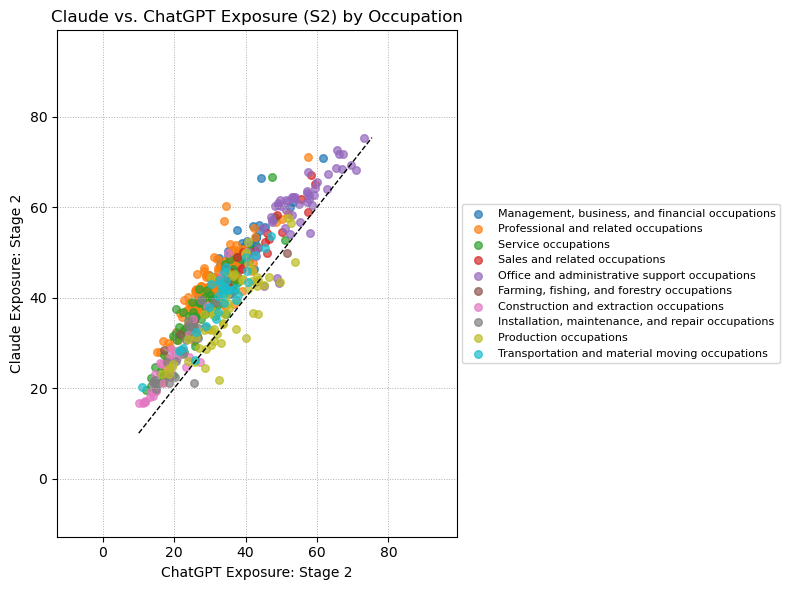

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Define group mapping based on CPS occupation codes
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

# Determine global min and max across all relevant OpenAI and Claude variables
exposure_columns = ['openai1', 'openai2', 'openai3', 'openai4', 'openai5',
                    'claude1', 'claude2', 'claude3', 'claude4', 'claude5',
                    'd_openai_S3_S1', 'd_claude_S3_S1', 'd_openai_S3_S2',
                    'd_claude_S3_S2', 'd_openai_S2_S1', 'd_claude_S2_S1']

# Get global min/max across all
global_min = df[exposure_columns].min().min()
global_max = df[exposure_columns].max().max()

# Optionally pad the limits a bit for nicer plotting
buffer = 2
global_lims = [global_min - buffer, global_max + buffer]

# Assign group label
def assign_group(code):
    for group, code_range in group_map.items():
        if code in code_range:
            return group
    return 'Unclassified'

df['group'] = df['cps_code'].apply(assign_group)

# Subset needed variables
df['openai_delta'] = df['openai2']
df['claude_delta'] = df['claude2']

# Set up plot
fig, ax = plt.subplots(figsize=(8, 6))

# Assign colors for groups
group_colors = {
    group: color for group, color in zip(df['group'].unique(), plt.cm.tab10.colors)
}

# Plot by group
for group, color in group_colors.items():
    sub = df[df['group'] == group]
    ax.scatter(
        sub['openai_delta'], sub['claude_delta'],
        label=group, alpha=0.7, s=30, color=color
    )

# Add 45-degree line
lims = [
    np.min([df['openai_delta'].min(), df['claude_delta'].min()]),
    np.max([df['openai_delta'].max(), df['claude_delta'].max()])
]
ax.plot(lims, lims, 'k--', linewidth=1)

# Axis labels and title
ax.set_xlabel("ChatGPT Exposure: Stage 2")
ax.set_ylabel("Claude Exposure: Stage 2")
ax.set_title("Claude vs. ChatGPT Exposure (S2) by Occupation")

# Format and legend
ax.grid(True, linestyle=':', linewidth=0.7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)


# Set consistent axis limits
ax.set_xlim(global_lims)
ax.set_ylim(global_lims)

plt.tight_layout()
plt.savefig("Output/Draft_5_20/III_Data/S2_scatter_by_group.png", dpi=300, bbox_inches='tight')
plt.show()


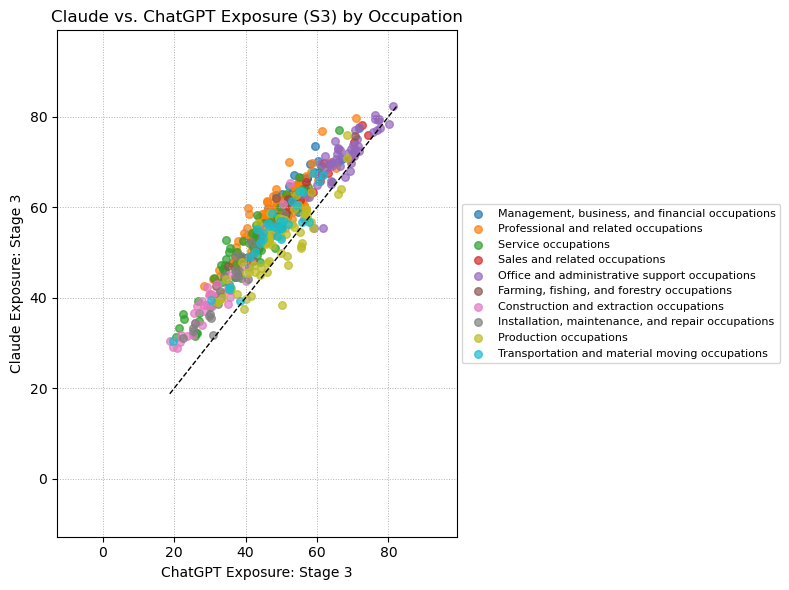

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Define group mapping based on CPS occupation codes
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

# Determine global min and max across all relevant OpenAI and Claude variables
exposure_columns = ['openai1', 'openai2', 'openai3', 'openai4', 'openai5',
                    'claude1', 'claude2', 'claude3', 'claude4', 'claude5',
                    'd_openai_S3_S1', 'd_claude_S3_S1', 'd_openai_S3_S2',
                    'd_claude_S3_S2', 'd_openai_S2_S1', 'd_claude_S2_S1']

# Get global min/max across all
global_min = df[exposure_columns].min().min()
global_max = df[exposure_columns].max().max()

# Optionally pad the limits a bit for nicer plotting
buffer = 2
global_lims = [global_min - buffer, global_max + buffer]

# Assign group label
def assign_group(code):
    for group, code_range in group_map.items():
        if code in code_range:
            return group
    return 'Unclassified'

df['group'] = df['cps_code'].apply(assign_group)

# Subset needed variables
df['openai_delta'] = df['openai3']
df['claude_delta'] = df['claude3']

# Set up plot
fig, ax = plt.subplots(figsize=(8, 6))

# Assign colors for groups
group_colors = {
    group: color for group, color in zip(df['group'].unique(), plt.cm.tab10.colors)
}

# Plot by group
for group, color in group_colors.items():
    sub = df[df['group'] == group]
    ax.scatter(
        sub['openai_delta'], sub['claude_delta'],
        label=group, alpha=0.7, s=30, color=color
    )

# Add 45-degree line
lims = [
    np.min([df['openai_delta'].min(), df['claude_delta'].min()]),
    np.max([df['openai_delta'].max(), df['claude_delta'].max()])
]
ax.plot(lims, lims, 'k--', linewidth=1)

# Axis labels and title
ax.set_xlabel("ChatGPT Exposure: Stage 3")
ax.set_ylabel("Claude Exposure: Stage 3")
ax.set_title("Claude vs. ChatGPT Exposure (S3) by Occupation")

# Format and legend
ax.grid(True, linestyle=':', linewidth=0.7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)


# Set consistent axis limits
ax.set_xlim(global_lims)
ax.set_ylim(global_lims)

plt.tight_layout()
plt.savefig("Output/Draft_5_20/III_Data/S3_scatter_by_group.png", dpi=300, bbox_inches='tight')
plt.show()


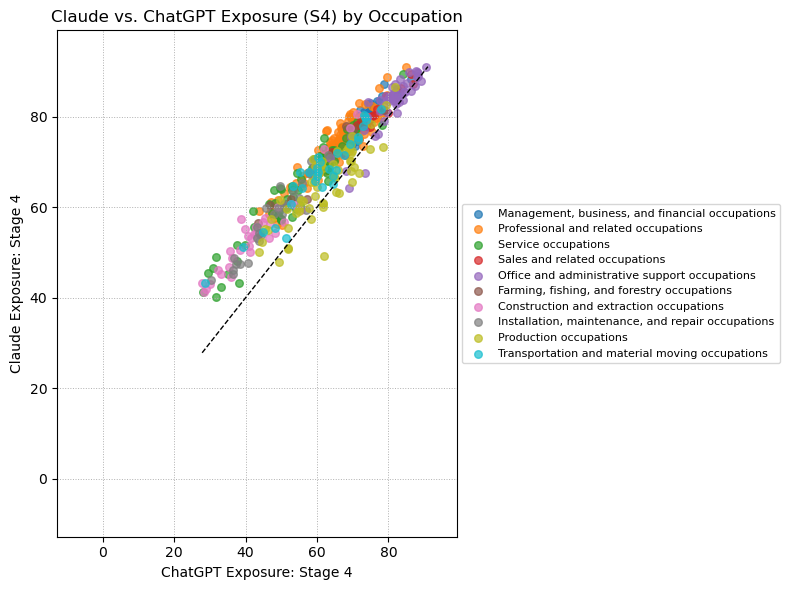

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Define group mapping based on CPS occupation codes
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

# Determine global min and max across all relevant OpenAI and Claude variables
exposure_columns = ['openai1', 'openai2', 'openai3', 'openai4', 'openai5',
                    'claude1', 'claude2', 'claude3', 'claude4', 'claude5',
                    'd_openai_S3_S1', 'd_claude_S3_S1', 'd_openai_S3_S2',
                    'd_claude_S3_S2', 'd_openai_S2_S1', 'd_claude_S2_S1']

# Get global min/max across all
global_min = df[exposure_columns].min().min()
global_max = df[exposure_columns].max().max()

# Optionally pad the limits a bit for nicer plotting
buffer = 2
global_lims = [global_min - buffer, global_max + buffer]

# Assign group label
def assign_group(code):
    for group, code_range in group_map.items():
        if code in code_range:
            return group
    return 'Unclassified'

df['group'] = df['cps_code'].apply(assign_group)

# Subset needed variables
df['openai_delta'] = df['openai4']
df['claude_delta'] = df['claude4']

# Set up plot
fig, ax = plt.subplots(figsize=(8, 6))

# Assign colors for groups
group_colors = {
    group: color for group, color in zip(df['group'].unique(), plt.cm.tab10.colors)
}

# Plot by group
for group, color in group_colors.items():
    sub = df[df['group'] == group]
    ax.scatter(
        sub['openai_delta'], sub['claude_delta'],
        label=group, alpha=0.7, s=30, color=color
    )

# Add 45-degree line
lims = [
    np.min([df['openai_delta'].min(), df['claude_delta'].min()]),
    np.max([df['openai_delta'].max(), df['claude_delta'].max()])
]
ax.plot(lims, lims, 'k--', linewidth=1)

# Axis labels and title
ax.set_xlabel("ChatGPT Exposure: Stage 4")
ax.set_ylabel("Claude Exposure: Stage 4")
ax.set_title("Claude vs. ChatGPT Exposure (S4) by Occupation")

# Format and legend
ax.grid(True, linestyle=':', linewidth=0.7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)


# Set consistent axis limits
ax.set_xlim(global_lims)
ax.set_ylim(global_lims)

plt.tight_layout()
plt.savefig("Output/Draft_5_20/III_Data/S4_scatter_by_group.png", dpi=300, bbox_inches='tight')
plt.show()


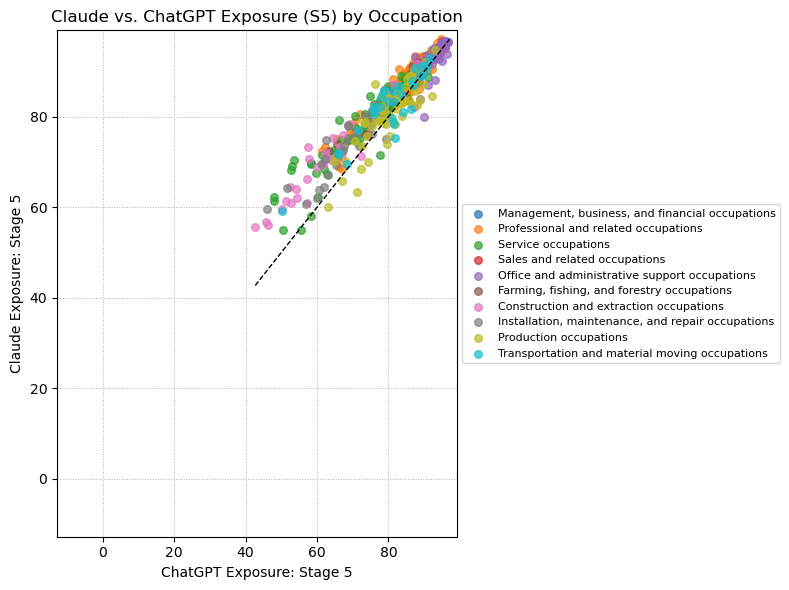

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Define group mapping based on CPS occupation codes
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

# Determine global min and max across all relevant OpenAI and Claude variables
exposure_columns = ['openai1', 'openai2', 'openai3', 'openai4', 'openai5',
                    'claude1', 'claude2', 'claude3', 'claude4', 'claude5',
                    'd_openai_S3_S1', 'd_claude_S3_S1', 'd_openai_S3_S2',
                    'd_claude_S3_S2', 'd_openai_S2_S1', 'd_claude_S2_S1']

# Get global min/max across all
global_min = df[exposure_columns].min().min()
global_max = df[exposure_columns].max().max()

# Optionally pad the limits a bit for nicer plotting
buffer = 2
global_lims = [global_min - buffer, global_max + buffer]

# Assign group label
def assign_group(code):
    for group, code_range in group_map.items():
        if code in code_range:
            return group
    return 'Unclassified'

df['group'] = df['cps_code'].apply(assign_group)

# Subset needed variables
df['openai_delta'] = df['openai5']
df['claude_delta'] = df['claude5']

# Set up plot
fig, ax = plt.subplots(figsize=(8, 6))

# Assign colors for groups
group_colors = {
    group: color for group, color in zip(df['group'].unique(), plt.cm.tab10.colors)
}

# Plot by group
for group, color in group_colors.items():
    sub = df[df['group'] == group]
    ax.scatter(
        sub['openai_delta'], sub['claude_delta'],
        label=group, alpha=0.7, s=30, color=color
    )

# Add 45-degree line
lims = [
    np.min([df['openai_delta'].min(), df['claude_delta'].min()]),
    np.max([df['openai_delta'].max(), df['claude_delta'].max()])
]
ax.plot(lims, lims, 'k--', linewidth=1)

# Axis labels and title
ax.set_xlabel("ChatGPT Exposure: Stage 5")
ax.set_ylabel("Claude Exposure: Stage 5")
ax.set_title("Claude vs. ChatGPT Exposure (S5) by Occupation")

# Format and legend
ax.grid(True, linestyle=':', linewidth=0.7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)


# Set consistent axis limits
ax.set_xlim(global_lims)
ax.set_ylim(global_lims)

plt.tight_layout()
plt.savefig("Output/Draft_5_20/III_Data/S5_scatter_by_group.png", dpi=300, bbox_inches='tight')
plt.show()


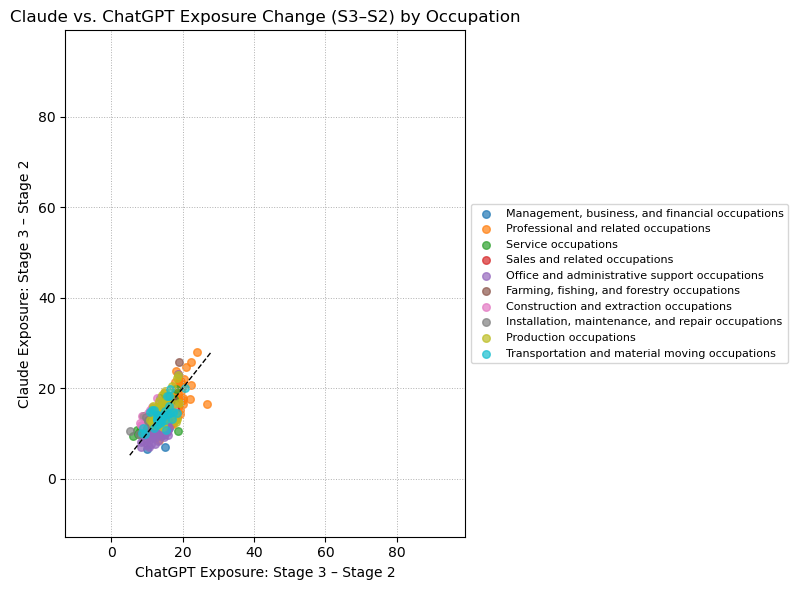

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Define group mapping based on CPS occupation codes
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

# Determine global min and max across all relevant OpenAI and Claude variables
exposure_columns = ['openai1', 'openai2', 'openai3', 'openai4', 'openai5',
                    'claude1', 'claude2', 'claude3', 'claude4', 'claude5',
                    'd_openai_S3_S1', 'd_claude_S3_S1', 'd_openai_S3_S2',
                    'd_claude_S3_S2', 'd_openai_S2_S1', 'd_claude_S2_S1']

# Get global min/max across all
global_min = df[exposure_columns].min().min()
global_max = df[exposure_columns].max().max()

# Optionally pad the limits a bit for nicer plotting
buffer = 2
global_lims = [global_min - buffer, global_max + buffer]


# Assign group label
def assign_group(code):
    for group, code_range in group_map.items():
        if code in code_range:
            return group
    return 'Unclassified'

df['group'] = df['cps_code'].apply(assign_group)

# Subset needed variables
df['openai_delta'] = df['d_openai_S3_S2']
df['claude_delta'] = df['d_claude_S3_S2']

# Set up plot
fig, ax = plt.subplots(figsize=(8, 6))

# Assign colors for groups
group_colors = {
    group: color for group, color in zip(df['group'].unique(), plt.cm.tab10.colors)
}

# Plot by group
for group, color in group_colors.items():
    sub = df[df['group'] == group]
    ax.scatter(
        sub['openai_delta'], sub['claude_delta'],
        label=group, alpha=0.7, s=30, color=color
    )

# Add 45-degree line
lims = [
    np.min([df['openai_delta'].min(), df['claude_delta'].min()]),
    np.max([df['openai_delta'].max(), df['claude_delta'].max()])
]
ax.plot(lims, lims, 'k--', linewidth=1)

# Axis labels and title
ax.set_xlabel("ChatGPT Exposure: Stage 3 – Stage 2")
ax.set_ylabel("Claude Exposure: Stage 3 – Stage 2")
ax.set_title("Claude vs. ChatGPT Exposure Change (S3–S2) by Occupation")

# Format and legend
ax.grid(True, linestyle=':', linewidth=0.7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

# Set consistent axis limits
ax.set_xlim(global_lims)
ax.set_ylim(global_lims)

plt.tight_layout()
plt.savefig("Output/Draft_5_20/III_Data/3_2_scatter_by_group.png", dpi=300, bbox_inches='tight')
plt.show()


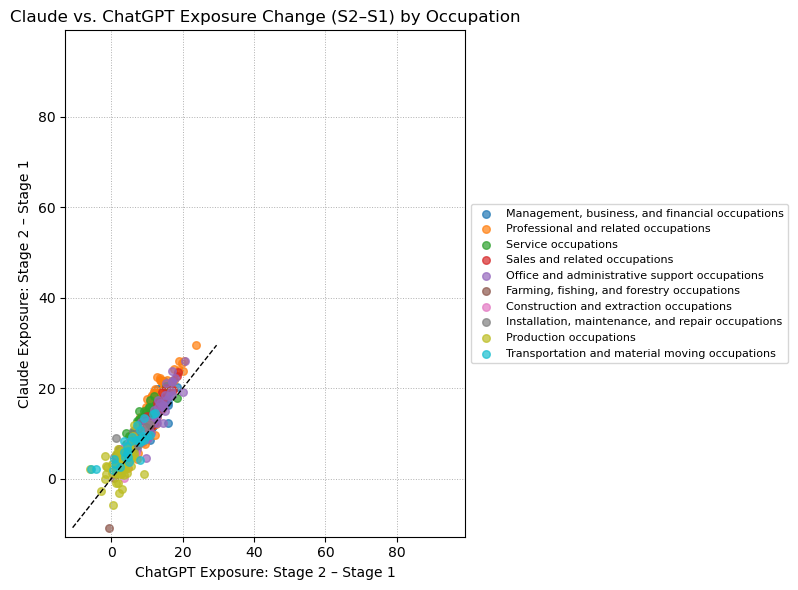

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your data
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Define group mapping based on CPS occupation codes
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

# Determine global min and max across all relevant OpenAI and Claude variables
exposure_columns = ['openai1', 'openai2', 'openai3', 'openai4', 'openai5',
                    'claude1', 'claude2', 'claude3', 'claude4', 'claude5',
                    'd_openai_S3_S1', 'd_claude_S3_S1', 'd_openai_S3_S2',
                    'd_claude_S3_S2', 'd_openai_S2_S1', 'd_claude_S2_S1']

# Get global min/max across all
global_min = df[exposure_columns].min().min()
global_max = df[exposure_columns].max().max()

# Optionally pad the limits a bit for nicer plotting
buffer = 2
global_lims = [global_min - buffer, global_max + buffer]


# Assign group label
def assign_group(code):
    for group, code_range in group_map.items():
        if code in code_range:
            return group
    return 'Unclassified'

df['group'] = df['cps_code'].apply(assign_group)

# Subset needed variables
df['openai_delta'] = df['d_openai_S2_S1']
df['claude_delta'] = df['d_claude_S2_S1']

# Set up plot
fig, ax = plt.subplots(figsize=(8, 6))

# Assign colors for groups
group_colors = {
    group: color for group, color in zip(df['group'].unique(), plt.cm.tab10.colors)
}

# Plot by group
for group, color in group_colors.items():
    sub = df[df['group'] == group]
    ax.scatter(
        sub['openai_delta'], sub['claude_delta'],
        label=group, alpha=0.7, s=30, color=color
    )

# Add 45-degree line
lims = [
    np.min([df['openai_delta'].min(), df['claude_delta'].min()]),
    np.max([df['openai_delta'].max(), df['claude_delta'].max()])
]
ax.plot(lims, lims, 'k--', linewidth=1)

# Axis labels and title
ax.set_xlabel("ChatGPT Exposure: Stage 2 – Stage 1")
ax.set_ylabel("Claude Exposure: Stage 2 – Stage 1")
ax.set_title("Claude vs. ChatGPT Exposure Change (S2–S1) by Occupation")

# Format and legend
ax.grid(True, linestyle=':', linewidth=0.7)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

# Set consistent axis limits
ax.set_xlim(global_lims)
ax.set_ylim(global_lims)

plt.tight_layout()
plt.savefig("Output/Draft_5_20/III_Data/2_1_scatter_by_group.png", dpi=300, bbox_inches='tight')
plt.show()


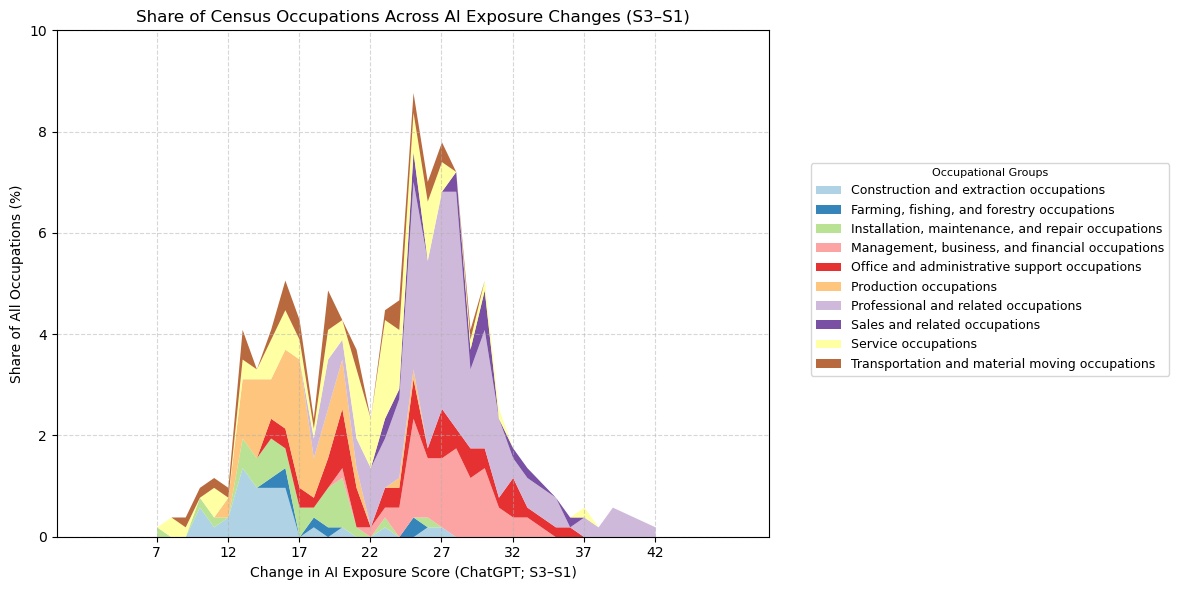

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

# Load your dataset
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# Census occupation group mapping
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

# Assign major group
def assign_group(code):
    for group, code_range in group_map.items():
        if int(code) in code_range:
            return group
    return 'Unclassified'

df["group"] = df["cps_code"].apply(assign_group)

# Drop missing values
df = df.dropna(subset=["d_openai_S3_S1", "group"])

# Bin exposure scores
bins = np.arange(7, 45, 1)
df["exposure_bin"] = pd.cut(df["d_openai_S3_S1"], bins=bins, labels=bins[:-1], include_lowest=True)

# Count occupations by bin and group
occ_counts = df.groupby(["exposure_bin", "group"], observed=True).size().unstack(fill_value=0)

# Convert to percent of all occupations
total_occ = len(df)
occ_pct_total = occ_counts.div(total_occ).multiply(100)

# Ensure x-axis bins are numeric and sorted
occ_pct_total.index = occ_pct_total.index.astype(int)
occ_pct_total = occ_pct_total.sort_index()

fig, ax = plt.subplots(figsize=(12, 6))  # THIS is the key
occ_pct_total.plot(
    kind="area",
    stacked=True,
    colormap="Paired",
    alpha=0.9,
    linewidth=0,
    ax=ax  # use the axis you've explicitly created
)

ax.set_xlabel("Change in AI Exposure Score (ChatGPT; S3–S1)")
ax.set_ylabel("Share of All Occupations (%)")
ax.set_title("Share of Census Occupations Across AI Exposure Changes (S3–S1)")
ax.set_xlim(0, 50)
ax.set_ylim(0, 10)
ax.legend(title="Occupational Groups", bbox_to_anchor=(1.05, 0.75), loc="upper left", fontsize=9, title_fontsize=8)
ax.grid(True, linestyle="--", alpha=0.5)

plt.xticks(np.arange(7, 45, 5))
plt.tight_layout()
plt.savefig("Output/Draft_5_20/III_Data/exp_occ_pct_true_3_1.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/pw/rvl88q8j7599v3sdt405cx1w0000gq/T/ipykernel_24512/480805913.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["group"] = df["cps_code"].apply(assign_group)


<Figure size 1200x600 with 0 Axes>

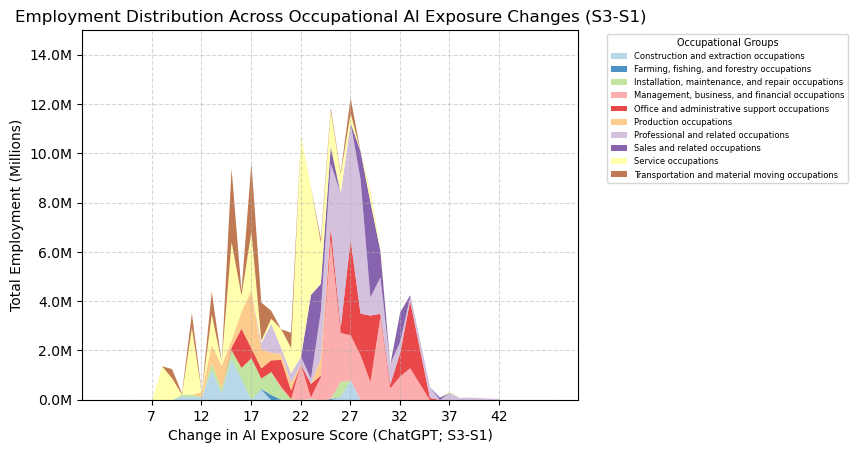

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
file_path = "/Users/jdomins2/Desktop/CPS_Work/Data/Cleaned/oews_analysis.dta"
df = pd.read_stata(file_path)

# Define AI exposure column and employment column
exposure_column = "d_openai_S3_S1"  # Update this based on the stage you're visualizing
employment_column = "tot_emp_24"

# Census occupation group mapping
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

# Assign major group
def assign_group(code):
    for group, code_range in group_map.items():
        if int(code) in code_range:
            return group
    return 'Unclassified'

df["group"] = df["cps_code"].apply(assign_group)


# Drop missing values
df = df.dropna(subset=["d_openai_S3_S1", "group"])

# Bin exposure scores into fixed intervals (ensuring numerical bins)
bins = np.arange(7, 44, 1)  # ~1 bin per 1 unit of change
df["exposure_bin"] = pd.cut(df[exposure_column], bins, labels=bins[:-1], include_lowest=True)

# Aggregate employment by exposure bin and occupation group
employment_distribution = df.groupby(["exposure_bin", "group"], observed=True)[employment_column].sum().unstack()

# Ensure the bins are numeric for proper sorting
employment_distribution.index = employment_distribution.index.astype(float)

import matplotlib.ticker as mticker

# Create figure
plt.figure(figsize=(12, 6))

# Plot
employment_distribution.sort_index().plot(kind="area", stacked=True, colormap="Paired", alpha=0.8, linewidth=0)

# Formatting the plot
plt.xlabel("Change in AI Exposure Score (ChatGPT; S3-S1)")
plt.ylabel("Total Employment (Millions)")
plt.title("Employment Distribution Across Occupational AI Exposure Changes (S3-S1)")
plt.legend(title="Occupational Groups", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=6, title_fontsize=7)
plt.grid(True, linestyle="--", alpha=0.5)
plt.xlim(0, 50)
plt.ylim(0, 15e6)

# Convert y-axis labels from scientific notation to millions
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M'))
plt.xticks(np.arange(7, 45, 5))

# Save and show the figure
plt.savefig("/Users/jdomins2/Desktop/CPS_Work/Output/Draft_5_20/III_Data/exp_emp_census_occ.png", dpi=300, bbox_inches="tight")
plt.show()


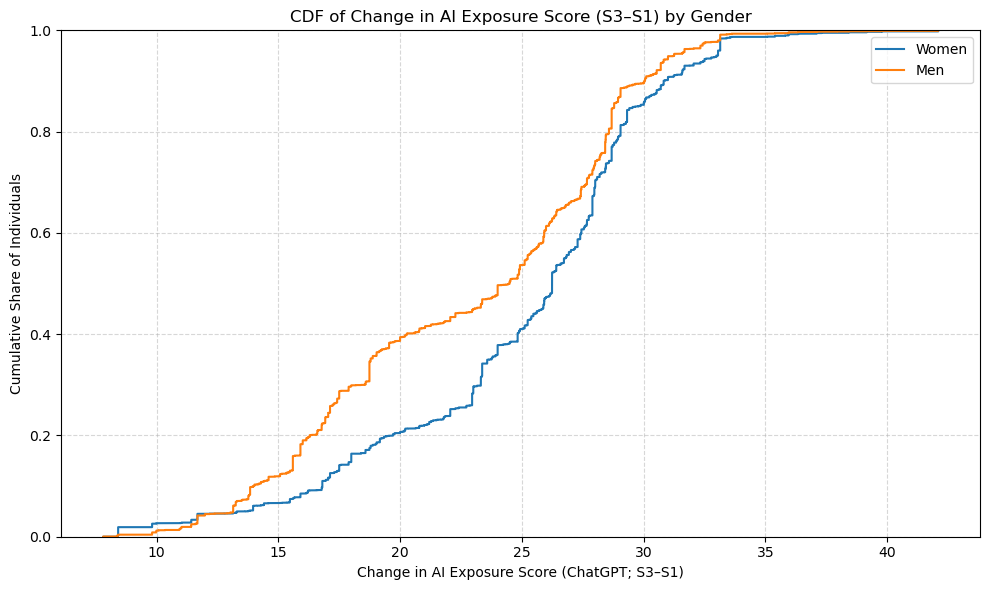

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop missing values
df = df.dropna(subset=["d_openai_S3_S1", "Dfem", "wtfinl"])

# Create CDF plot
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df[df["Dfem"] == 1], x="d_openai_S3_S1", label="Women", weights=df[df["Dfem"] == 1]["wtfinl"])
sns.ecdfplot(data=df[df["Dfem"] == 0], x="d_openai_S3_S1", label="Men", weights=df[df["Dfem"] == 0]["wtfinl"])

plt.title("CDF of Change in AI Exposure Score (S3–S1) by Gender")
plt.xlabel("Change in AI Exposure Score (ChatGPT; S3–S1)")
plt.ylabel("Cumulative Share of Individuals")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Output/Draft_5_20/cdf_exposure_gender.png", dpi=300)
plt.show()


/var/folders/pw/rvl88q8j7599v3sdt405cx1w0000gq/T/ipykernel_24512/1841252251.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  avg_exposure_by_gender = df.groupby("Dfem").apply(
/var/folders/pw/rvl88q8j7599v3sdt405cx1w0000gq/T/ipykernel_24512/1841252251.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_exposure_by_gender, x="gender", y="weighted_avg", palette="pastel")


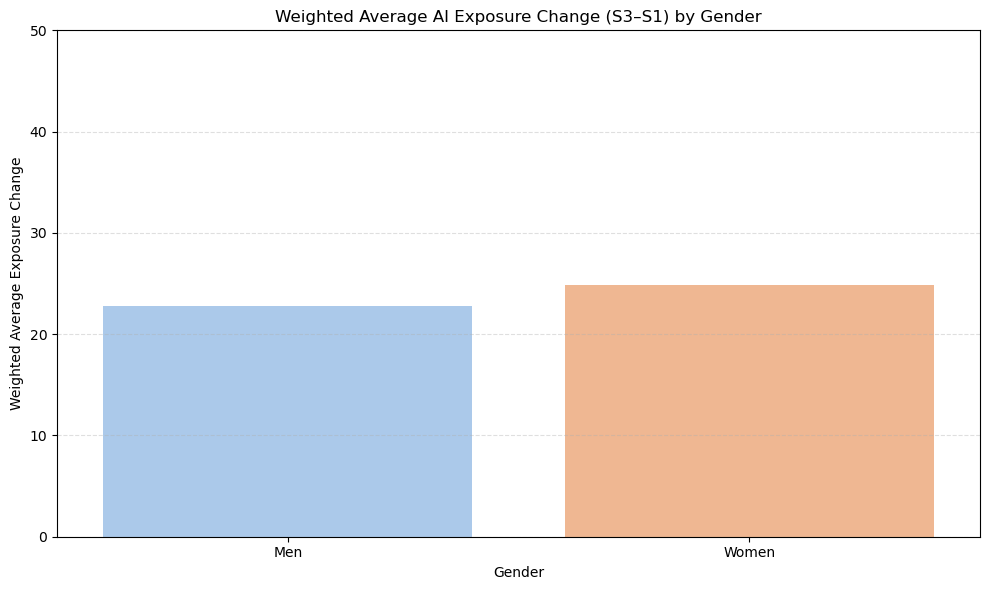

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop missing values
df = df.dropna(subset=["d_openai_S3_S1", "Dfem", "wtfinl"])

# Compute weighted means
avg_exposure_by_gender = df.groupby("Dfem").apply(
    lambda x: np.average(x["d_openai_S3_S1"], weights=x["wtfinl"])
).reset_index(name="weighted_avg")

# Map labels
avg_exposure_by_gender["gender"] = avg_exposure_by_gender["Dfem"].map({0: "Men", 1: "Women"})

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_exposure_by_gender, x="gender", y="weighted_avg", palette="pastel")
plt.title("Weighted Average AI Exposure Change (S3–S1) by Gender")
plt.ylabel("Weighted Average Exposure Change")
plt.xlabel("Gender")
plt.ylim(0, 50)
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("Output/Draft_5_20/avg_exposure_gender.png", dpi=300)
plt.show()


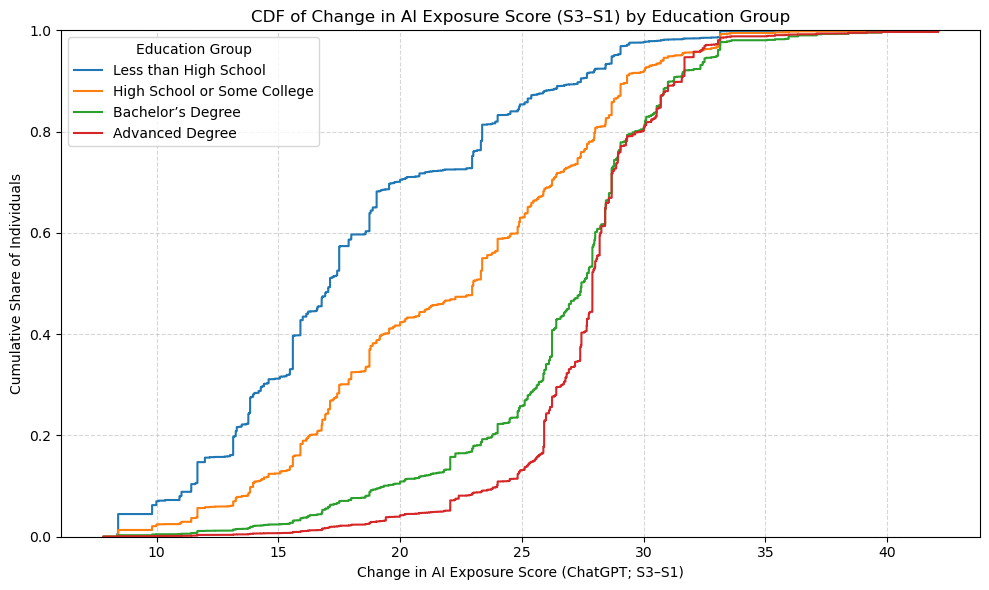

In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop missing values
df = df.dropna(subset=["d_openai_S3_S1", "wtfinl", "educ_q1", "educ_q2", "educ_q3", "educ_q4"])

# Set up the plot
plt.figure(figsize=(10, 6))

# Define group labels and colors (optional)
educ_groups = {
    "Less than High School": "educ_q1",
    "High School or Some College": "educ_q2",
    "Bachelor’s Degree": "educ_q3",
    "Advanced Degree": "educ_q4"
}

# Plot CDF for each education group
for label, col in educ_groups.items():
    subset = df[df[col] == 1]
    sns.ecdfplot(data=subset, x="d_openai_S3_S1", weights=subset["wtfinl"], label=label)

# Final formatting
plt.title("CDF of Change in AI Exposure Score (S3–S1) by Education Group")
plt.xlabel("Change in AI Exposure Score (ChatGPT; S3–S1)")
plt.ylabel("Cumulative Share of Individuals")
plt.legend(title="Education Group")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Output/Draft_5_20/cdf_exposure_education.png", dpi=300)
plt.show()


/var/folders/pw/rvl88q8j7599v3sdt405cx1w0000gq/T/ipykernel_24512/1194252422.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_exposure_by_educ, x="education", y="weighted_avg", palette="pastel")


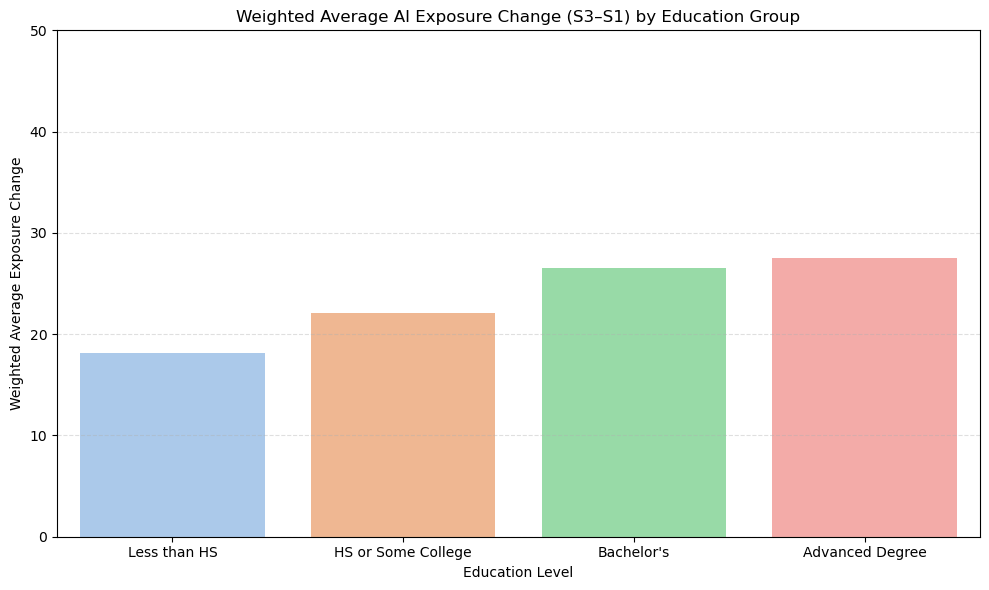

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop rows with missing values
df = df.dropna(subset=["d_openai_S3_S1", "wtfinl", "educ_q1", "educ_q2", "educ_q3", "educ_q4"])

# Define labels for each dummy variable
educ_map = {
    "educ_q1": "Less than HS",
    "educ_q2": "HS or Some College",
    "educ_q3": "Bachelor's",
    "educ_q4": "Advanced Degree"
}

# Calculate weighted average exposure for each education group
results = []
for var, label in educ_map.items():
    subset = df[df[var] == 1]
    weighted_avg = np.average(subset["d_openai_S3_S1"], weights=subset["wtfinl"])
    results.append({"education": label, "weighted_avg": weighted_avg})

avg_exposure_by_educ = pd.DataFrame(results)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_exposure_by_educ, x="education", y="weighted_avg", palette="pastel")

plt.title("Weighted Average AI Exposure Change (S3–S1) by Education Group")
plt.ylabel("Weighted Average Exposure Change")
plt.xlabel("Education Level")
plt.ylim(0, 50)
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("Output/Draft_5_20/avg_exposure_education.png", dpi=300)
plt.show()


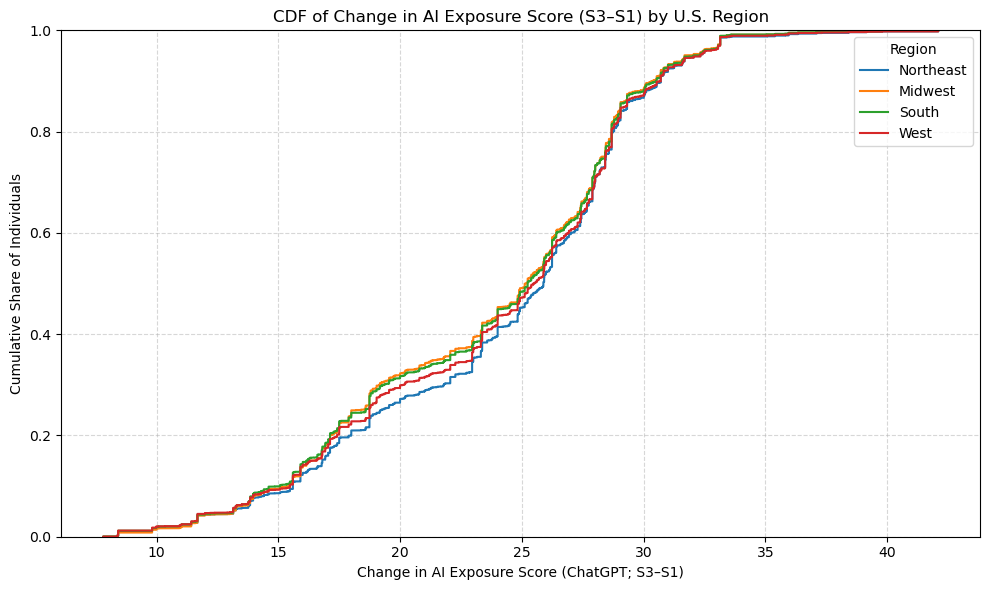

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop missing values
df = df.dropna(subset=["d_openai_S3_S1", "wtfinl", "d_northeast", "d_midwest", "d_south", "d_west"])

# Set up the plot
plt.figure(figsize=(10, 6))

# Define group labels and dummy variable names
region_groups = {
    "Northeast": "d_northeast",
    "Midwest": "d_midwest",
    "South": "d_south",
    "West": "d_west"
}

# Plot CDF for each region
for label, col in region_groups.items():
    subset = df[df[col] == 1]
    sns.ecdfplot(data=subset, x="d_openai_S3_S1", weights=subset["wtfinl"], label=label)

# Final formatting
plt.title("CDF of Change in AI Exposure Score (S3–S1) by U.S. Region")
plt.xlabel("Change in AI Exposure Score (ChatGPT; S3–S1)")
plt.ylabel("Cumulative Share of Individuals")
plt.legend(title="Region")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Output/Draft_5_20/cdf_exposure_region.png", dpi=300)
plt.show()


/var/folders/pw/rvl88q8j7599v3sdt405cx1w0000gq/T/ipykernel_24512/3397764825.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_exposure_by_region, x="region", y="weighted_avg", palette="pastel")


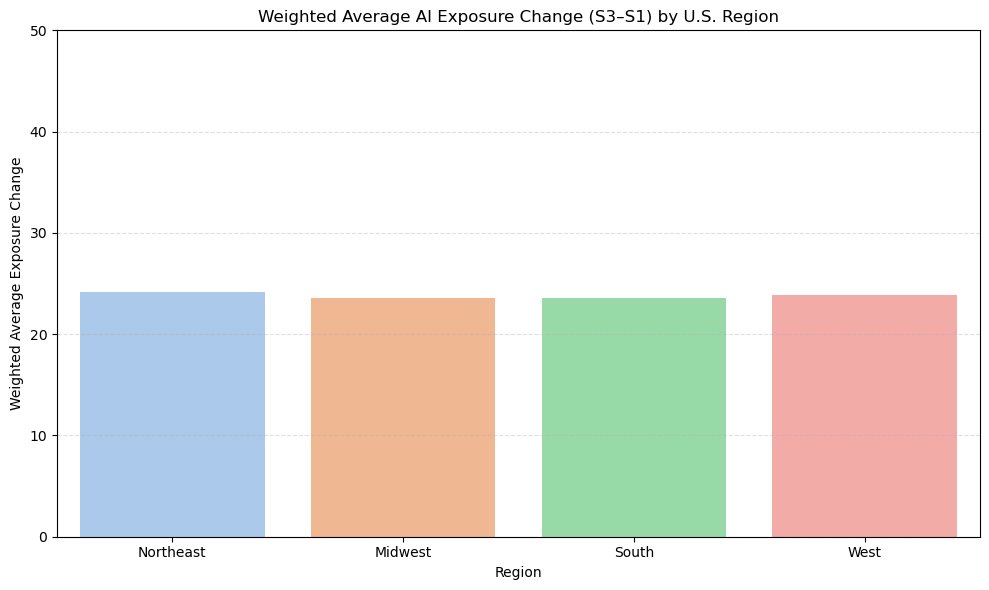

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop rows with missing values
df = df.dropna(subset=["d_openai_S3_S1", "wtfinl", "d_northeast", "d_midwest", "d_south", "d_west"])

# Define labels for each dummy variable
region_map = {
    "d_northeast": "Northeast",
    "d_midwest": "Midwest",
    "d_south": "South",
    "d_west": "West"
}

# Calculate weighted average exposure for each region
results = []
for var, label in region_map.items():
    subset = df[df[var] == 1]
    weighted_avg = np.average(subset["d_openai_S3_S1"], weights=subset["wtfinl"])
    results.append({"region": label, "weighted_avg": weighted_avg})

avg_exposure_by_region = pd.DataFrame(results)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_exposure_by_region, x="region", y="weighted_avg", palette="pastel")

plt.title("Weighted Average AI Exposure Change (S3–S1) by U.S. Region")
plt.ylabel("Weighted Average Exposure Change")
plt.xlabel("Region")
plt.ylim(0, 50)
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("Output/Draft_5_20/avg_exposure_region.png", dpi=300)
plt.show()


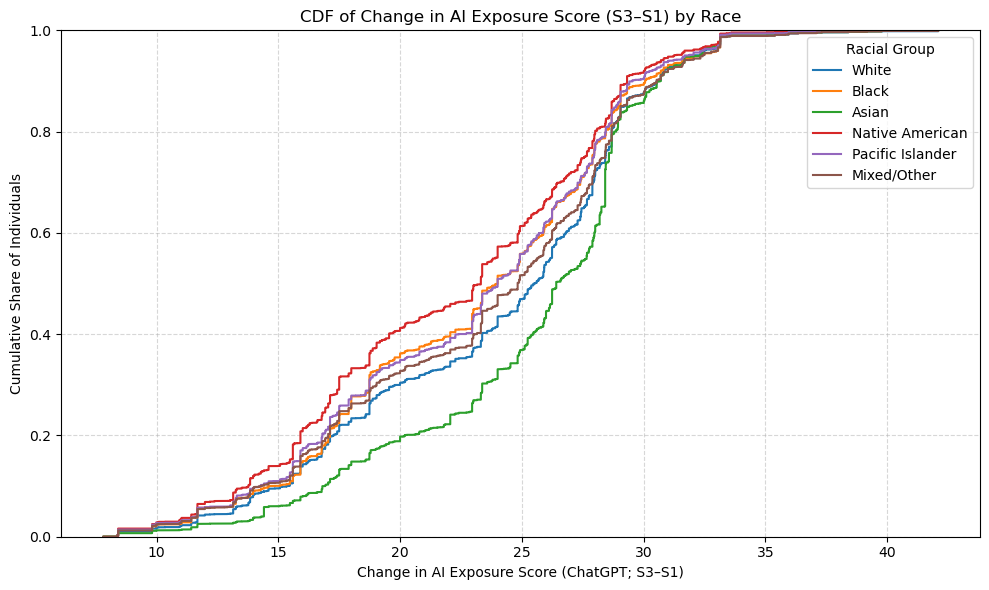

In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop rows with missing values
df = df.dropna(subset=[
    "d_openai_S3_S1", "wtfinl",
    "race_white", "race_black", "race_asian",
    "race_native", "race_pacific", "race_mixed_other"
])

# Define racial group labels and their corresponding dummy variable names
race_groups = {
    "White": "race_white",
    "Black": "race_black",
    "Asian": "race_asian",
    "Native American": "race_native",
    "Pacific Islander": "race_pacific",
    "Mixed/Other": "race_mixed_other"
}

# Plot setup
plt.figure(figsize=(10, 6))

# Plot CDFs
for label, col in race_groups.items():
    subset = df[df[col] == 1]
    sns.ecdfplot(data=subset, x="d_openai_S3_S1", weights=subset["wtfinl"], label=label)

# Final formatting
plt.title("CDF of Change in AI Exposure Score (S3–S1) by Race")
plt.xlabel("Change in AI Exposure Score (ChatGPT; S3–S1)")
plt.ylabel("Cumulative Share of Individuals")
plt.legend(title="Racial Group")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Output/Draft_5_20/cdf_exposure_race.png", dpi=300)
plt.show()


/var/folders/pw/rvl88q8j7599v3sdt405cx1w0000gq/T/ipykernel_24512/4121863054.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_exposure_by_race, x="race", y="weighted_avg", palette="pastel")


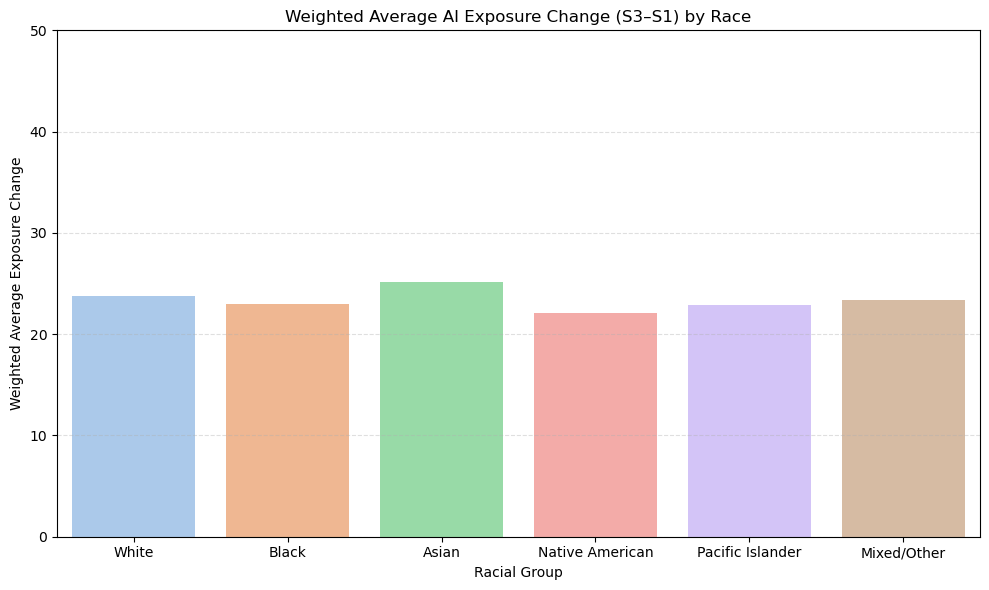

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop rows with missing values
df = df.dropna(subset=[
    "d_openai_S3_S1", "wtfinl",
    "race_white", "race_black", "race_asian",
    "race_native", "race_pacific", "race_mixed_other"
])

# Define mapping of dummy variables to readable labels
race_map = {
    "race_white": "White",
    "race_black": "Black",
    "race_asian": "Asian",
    "race_native": "Native American",
    "race_pacific": "Pacific Islander",
    "race_mixed_other": "Mixed/Other"
}

# Calculate weighted average exposure for each race group
results = []
for var, label in race_map.items():
    subset = df[df[var] == 1]
    if not subset.empty:
        weighted_avg = np.average(subset["d_openai_S3_S1"], weights=subset["wtfinl"])
        results.append({"race": label, "weighted_avg": weighted_avg})

avg_exposure_by_race = pd.DataFrame(results)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_exposure_by_race, x="race", y="weighted_avg", palette="pastel")

plt.title("Weighted Average AI Exposure Change (S3–S1) by Race")
plt.ylabel("Weighted Average Exposure Change")
plt.xlabel("Racial Group")
plt.ylim(0, 50)
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("Output/Draft_5_20/avg_exposure_race.png", dpi=300)
plt.show()


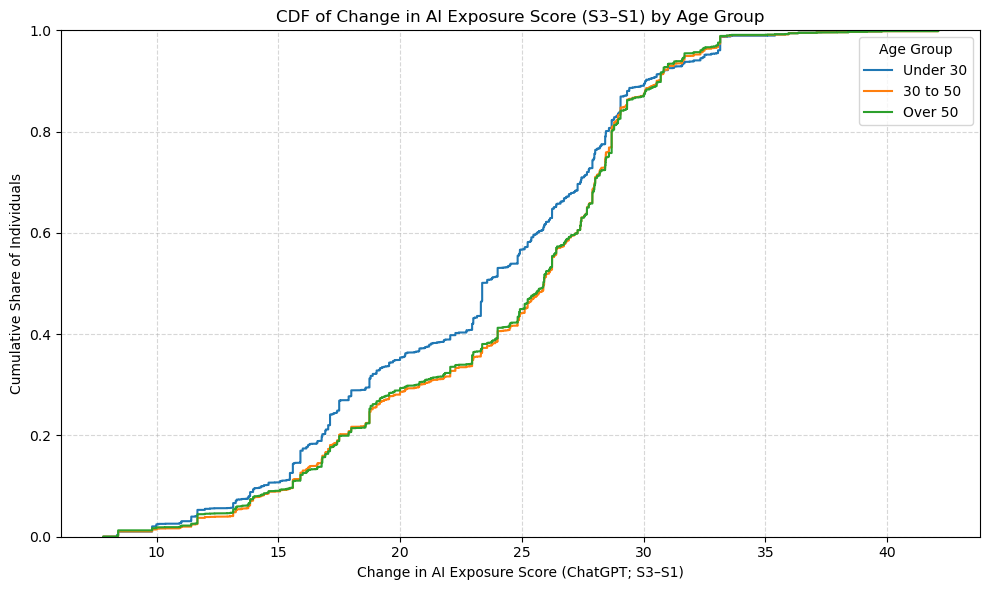

In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop missing values for exposure, weights, and age group dummies
df = df.dropna(subset=["d_openai_S3_S1", "wtfinl", "age_30less", "age_30to50", "age_50plus"])

# ---------------- CDF Plot ----------------
plt.figure(figsize=(10, 6))

age_groups = {
    "Under 30": "age_30less",
    "30 to 50": "age_30to50",
    "Over 50": "age_50plus"
}

for label, col in age_groups.items():
    subset = df[df[col] == 1]
    sns.ecdfplot(data=subset, x="d_openai_S3_S1", weights=subset["wtfinl"], label=label)

plt.title("CDF of Change in AI Exposure Score (S3–S1) by Age Group")
plt.xlabel("Change in AI Exposure Score (ChatGPT; S3–S1)")
plt.ylabel("Cumulative Share of Individuals")
plt.legend(title="Age Group")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Output/Draft_5_20/cdf_exposure_agegroup.png", dpi=300)
plt.show()

/var/folders/pw/rvl88q8j7599v3sdt405cx1w0000gq/T/ipykernel_24512/3918698121.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_exposure_by_age, x="age_group", y="weighted_avg", palette="pastel")


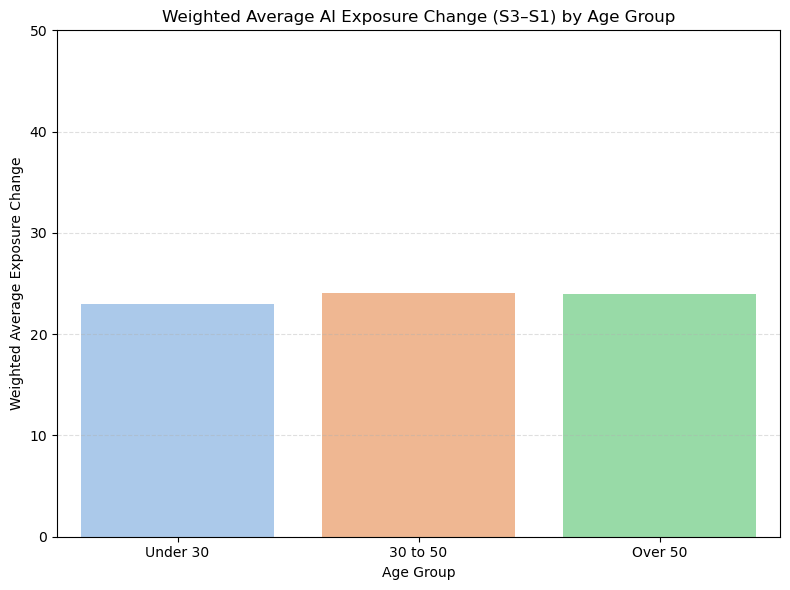

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop missing values for exposure, weights, and age group dummies
df = df.dropna(subset=["d_openai_S3_S1", "wtfinl", "age_30less", "age_30to50", "age_50plus"])

results = []
for label, col in age_groups.items():
    subset = df[df[col] == 1]
    weighted_avg = np.average(subset["d_openai_S3_S1"], weights=subset["wtfinl"])
    results.append({"age_group": label, "weighted_avg": weighted_avg})

avg_exposure_by_age = pd.DataFrame(results)

plt.figure(figsize=(8, 6))
sns.barplot(data=avg_exposure_by_age, x="age_group", y="weighted_avg", palette="pastel")
plt.title("Weighted Average AI Exposure Change (S3–S1) by Age Group")
plt.ylabel("Weighted Average Exposure Change")
plt.xlabel("Age Group")
plt.ylim(0, 50)
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("Output/Draft_5_20/avg_exposure_agegroup.png", dpi=300)
plt.show()


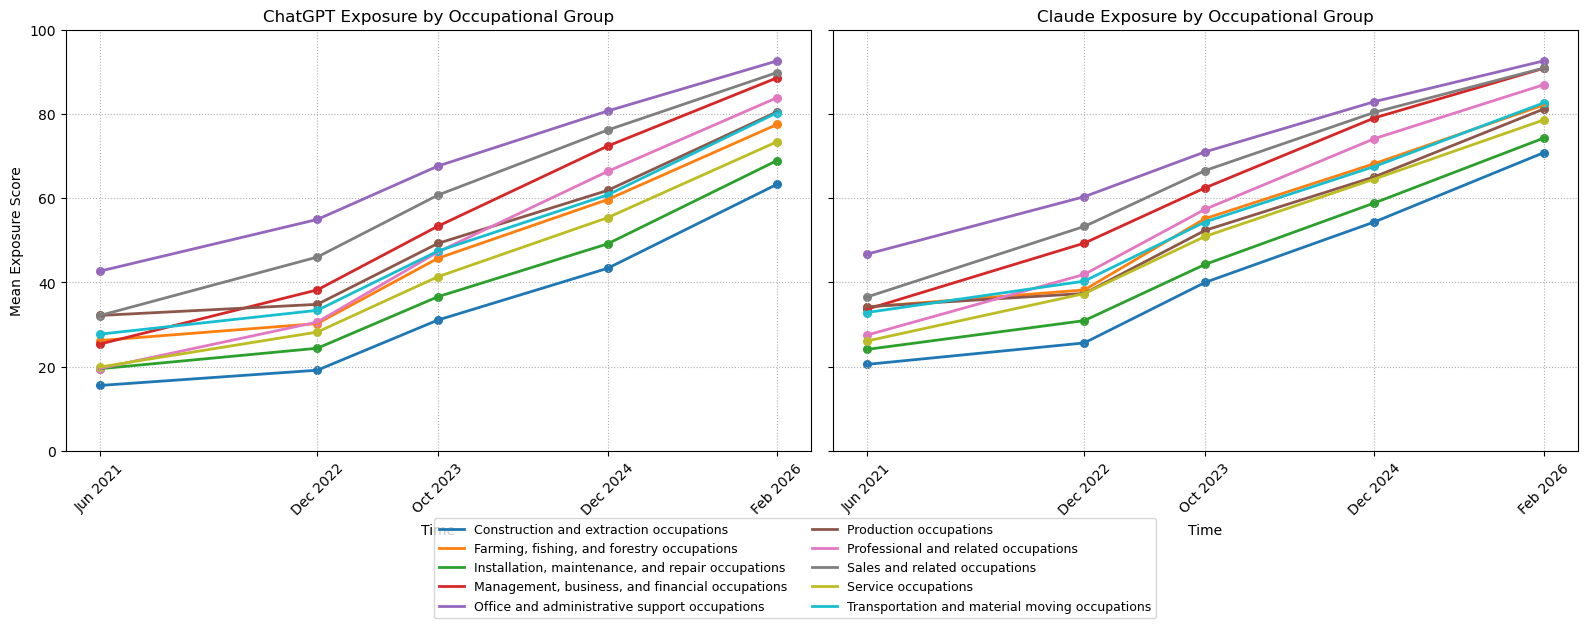

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# === Load the data ===
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# === Define group mapping ===
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

def assign_group(code):
    for group, code_range in group_map.items():
        if code in code_range:
            return group
    return 'Unclassified'

df['group'] = df['cps_code'].apply(assign_group)

# === Set stage dates and labels ===
stage_dates = [
    datetime(2021, 6, 1),
    datetime(2022, 12, 1),
    datetime(2023, 10, 1),
    datetime(2024, 12, 1),
    datetime(2026, 2, 1)
]
stage_labels = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5']

# === Compute means ===
openai_cols = ['openai1', 'openai2', 'openai3', 'openai4', 'openai5']
claude_cols = ['claude1', 'claude2', 'claude3', 'claude4', 'claude5']
openai_means = df.groupby('group')[openai_cols].mean()
claude_means = df.groupby('group')[claude_cols].mean()

# === Plotting ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
colors = plt.cm.tab10.colors

# --- OpenAI subplot ---
for idx, group in enumerate(openai_means.index):
    y_vals = openai_means.loc[group].values
    ax1.plot(stage_dates, y_vals, color=colors[idx % 10], label=group, linewidth=2)
    ax1.scatter(stage_dates, y_vals, color=colors[idx % 10], s=30)  # dots at stage starts

ax1.set_title("ChatGPT Exposure by Occupational Group")
ax1.set_xlabel("Time")
ax1.set_ylabel("Mean Exposure Score")
ax1.set_xticks(stage_dates)
ax1.set_xticklabels([d.strftime('%b %Y') for d in stage_dates], rotation=45)
ax1.set_ylim(0, 100)
ax1.grid(True, linestyle=':', linewidth=0.8)

# --- Claude subplot ---
for idx, group in enumerate(claude_means.index):
    y_vals = claude_means.loc[group].values
    ax2.plot(stage_dates, y_vals, color=colors[idx % 10], linewidth=2)
    ax2.scatter(stage_dates, y_vals, color=colors[idx % 10], s=30)

ax2.set_title("Claude Exposure by Occupational Group")
ax2.set_xlabel("Time")
ax2.set_xticks(stage_dates)
ax2.set_xticklabels([d.strftime('%b %Y') for d in stage_dates], rotation=45)
ax2.grid(True, linestyle=':', linewidth=0.8)

# === Combined legend ===
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=9)

plt.tight_layout(rect=[0, 0.07, 1, 1])  # Leave space at bottom for legend
plt.savefig("Output/Draft_5_20/exp_by_group_dualpanel.png", dpi=300, bbox_inches='tight')
plt.show()


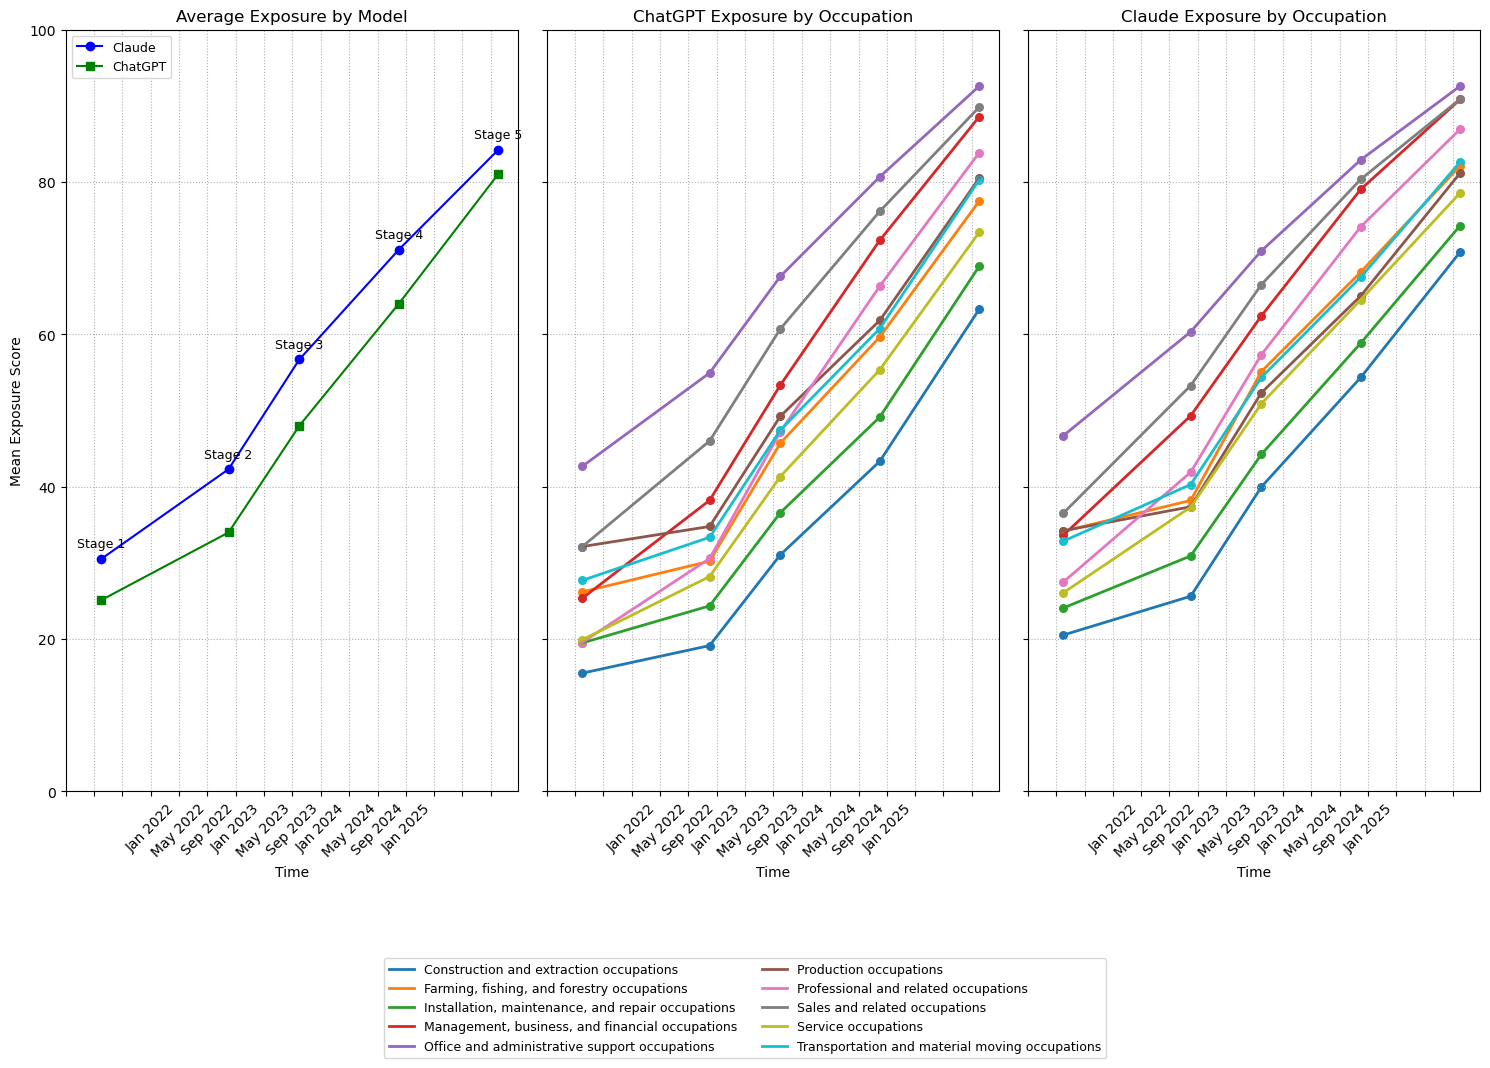

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# === Data for Panel A: Aggregate Exposure ===
df_agg = pd.DataFrame({
    'Date': [
        datetime(2021, 6, 1),
        datetime(2022, 12, 1),
        datetime(2023, 10, 1),
        datetime(2024, 12, 1),
        datetime(2026, 2, 1)
    ],
    'Claude': [30.5, 42.3, 56.7, 71.1, 84.2],
    'OpenAI': [25.1, 34.0, 48.0, 64.0, 81.0]
})
stage_labels = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4', 'Stage 5']
stage_dates = df_agg['Date']

# === Load group-level exposure data ===
df_group = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# === Define group mappings ===
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}
def assign_group(code):
    for group, code_range in group_map.items():
        if code in code_range:
            return group
    return 'Unclassified'
df_group['group'] = df_group['cps_code'].apply(assign_group)

# === Compute means ===
openai_cols = ['openai1', 'openai2', 'openai3', 'openai4', 'openai5']
claude_cols = ['claude1', 'claude2', 'claude3', 'claude4', 'claude5']
openai_means = df_group.groupby('group')[openai_cols].mean()
claude_means = df_group.groupby('group')[claude_cols].mean()

# === Setup plotting ===
fig, axes = plt.subplots(1, 3, figsize=(15, 10), sharey=True)
colors = plt.cm.tab10.colors

# === Define uniform x-axis ticks ===
all_xticks = pd.date_range(start='2021-01-01', end='2026-02-01', freq='4MS')
label_start = datetime(2022, 1, 1)
label_end = datetime(2025, 3, 1)
xtick_labels = [
    date.strftime('%b %Y') if label_start <= date <= label_end else ''
    for date in all_xticks
]

# === Panel A: Aggregate Exposure ===
ax = axes[0]
ax.plot(df_agg['Date'], df_agg['Claude'], marker='o', label='Claude', color='blue')
ax.plot(df_agg['Date'], df_agg['OpenAI'], marker='s', label='ChatGPT', color='green')
for i, label in enumerate(stage_labels):
    ax.text(df_agg['Date'][i], df_agg['Claude'][i] + 1.5, label, fontsize=9, ha='center')
ax.set_title("Average Exposure by Model")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Exposure Score")
ax.set_ylim(0, 100)
ax.grid(True, linestyle=':', linewidth=0.8)
ax.set_xticks(all_xticks)
ax.set_xticklabels(xtick_labels, rotation=45)
model_legend = ax.legend(fontsize=9, loc='upper left')

# === Panel B: ChatGPT by Occupation ===
ax = axes[1]
for idx, group in enumerate(openai_means.index):
    y_vals = openai_means.loc[group].values
    ax.plot(stage_dates, y_vals, color=colors[idx % 10], label=group, linewidth=2)
    ax.scatter(stage_dates, y_vals, color=colors[idx % 10], s=30)
ax.set_title("ChatGPT Exposure by Occupation")
ax.set_xlabel("Time")
ax.grid(True, linestyle=':', linewidth=0.8)
ax.set_xticks(all_xticks)
ax.set_xticklabels(xtick_labels, rotation=45)

# === Panel C: Claude by Occupation ===
ax = axes[2]
for idx, group in enumerate(claude_means.index):
    y_vals = claude_means.loc[group].values
    ax.plot(stage_dates, y_vals, color=colors[idx % 10], linewidth=2)
    ax.scatter(stage_dates, y_vals, color=colors[idx % 10], s=30)
ax.set_title("Claude Exposure by Occupation")
ax.set_xlabel("Time")
ax.grid(True, linestyle=':', linewidth=0.8)
ax.set_xticks(all_xticks)
ax.set_xticklabels(xtick_labels, rotation=45)

# === Shared Legend for Panels B and C ===
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.07), ncol=2, fontsize=9)

plt.tight_layout(rect=[0, 0.10, 1, 1])  # Space for shared legend
plt.savefig("Output/June/python/fig_2_4_combo.png", dpi=300, bbox_inches='tight')
plt.show()


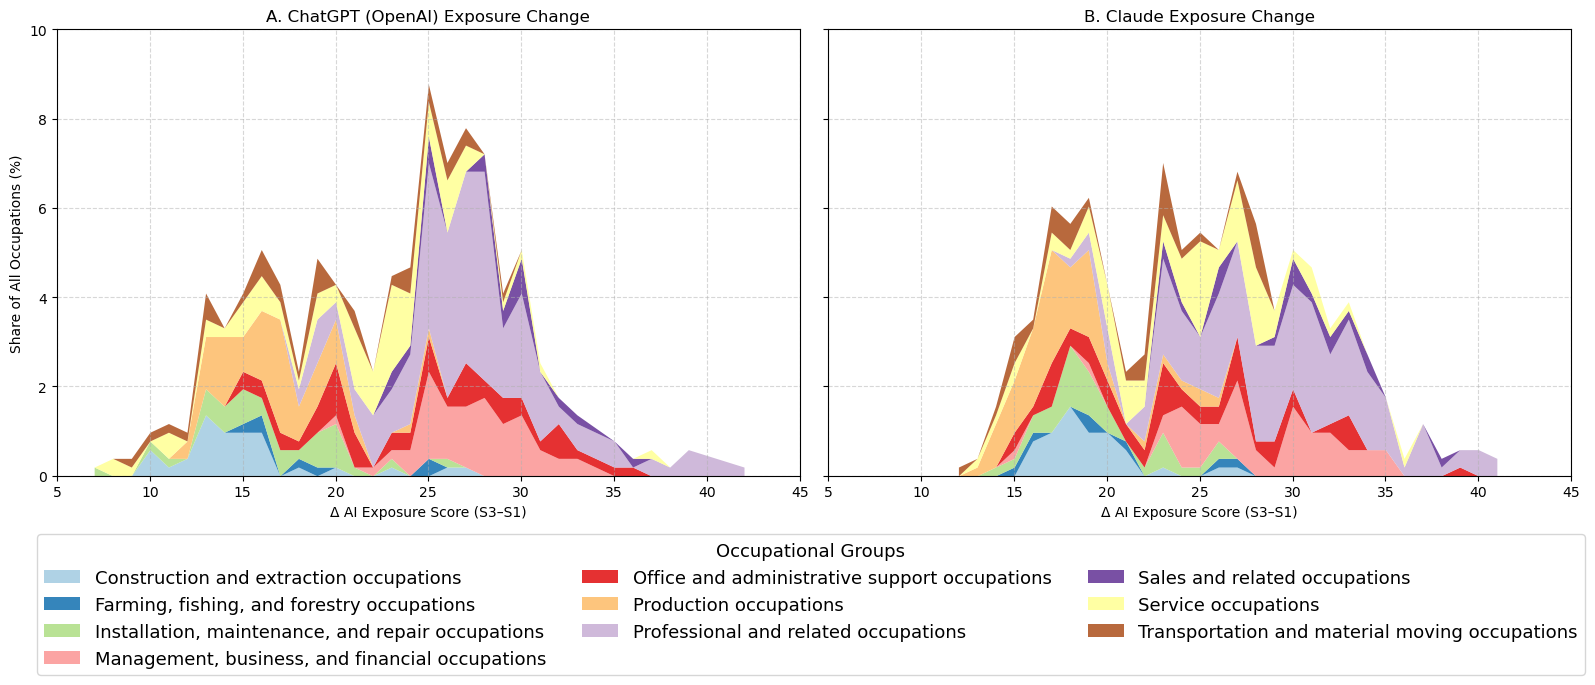

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Load and process the data ===
df = pd.read_stata("Data/Cleaned/P1_P4_ld_march2025_6M.dta")

# === Define Census occupation group mapping ===
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}

def assign_group(code):
    for group, code_range in group_map.items():
        if int(code) in code_range:
            return group
    return 'Unclassified'

df["group"] = df["cps_code"].apply(assign_group)

# === Define binning ===
bins = np.arange(7, 45, 1)

# === OpenAI processing ===
df_openai = df.dropna(subset=["d_openai_S3_S1", "group"]).copy()
df_openai["exposure_bin"] = pd.cut(df_openai["d_openai_S3_S1"], bins=bins, labels=bins[:-1], include_lowest=True)
occ_openai = df_openai.groupby(["exposure_bin", "group"], observed=True).size().unstack(fill_value=0)
occ_pct_openai = occ_openai.div(len(df_openai)).multiply(100)
occ_pct_openai.index = occ_pct_openai.index.astype(int)
occ_pct_openai = occ_pct_openai.sort_index()

# === Claude processing ===
df_claude = df.dropna(subset=["d_claude_S3_S1", "group"]).copy()
df_claude["exposure_bin"] = pd.cut(df_claude["d_claude_S3_S1"], bins=bins, labels=bins[:-1], include_lowest=True)
occ_claude = df_claude.groupby(["exposure_bin", "group"], observed=True).size().unstack(fill_value=0)
occ_pct_claude = occ_claude.div(len(df_claude)).multiply(100)
occ_pct_claude.index = occ_pct_claude.index.astype(int)
occ_pct_claude = occ_pct_claude.sort_index()

# === Plot setup ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
colors = plt.cm.Paired.colors

# === Panel A: ChatGPT (OpenAI) ===
occ_pct_openai.plot(
    kind="area", stacked=True, colormap="Paired", alpha=0.9, linewidth=0, ax=axes[0], legend=False
)
axes[0].set_title("A. ChatGPT (OpenAI) Exposure Change")
axes[0].set_xlabel("Δ AI Exposure Score (S3–S1)")
axes[0].set_ylabel("Share of All Occupations (%)")
axes[0].set_xlim(5, 45)
axes[0].set_ylim(0, 10)
axes[0].grid(True, linestyle="--", alpha=0.5)

# === Panel B: Claude ===
occ_pct_claude.plot(
    kind="area", stacked=True, colormap="Paired", alpha=0.9, linewidth=0, ax=axes[1], legend=False
)
axes[1].set_title("B. Claude Exposure Change")
axes[1].set_xlabel("Δ AI Exposure Score (S3–S1)")
axes[1].set_xlim(5, 45)
axes[1].grid(True, linestyle="--", alpha=0.5)

# === Shared Legend ===
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Occupational Groups",
    loc="lower center",
    ncol=3,
    fontsize=13,
    title_fontsize=13,
    bbox_to_anchor=(0.51, -0.15)
)

plt.tight_layout(rect=[0, 0.10, 1, 1])  # Increase space at bottom for legend
plt.savefig("Output/June/python/dual_exp_occ.png", dpi=300, bbox_inches="tight")
plt.show()


/var/folders/pw/rvl88q8j7599v3sdt405cx1w0000gq/T/ipykernel_72733/4210000875.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["group"] = df["cps_code"].apply(assign_group)


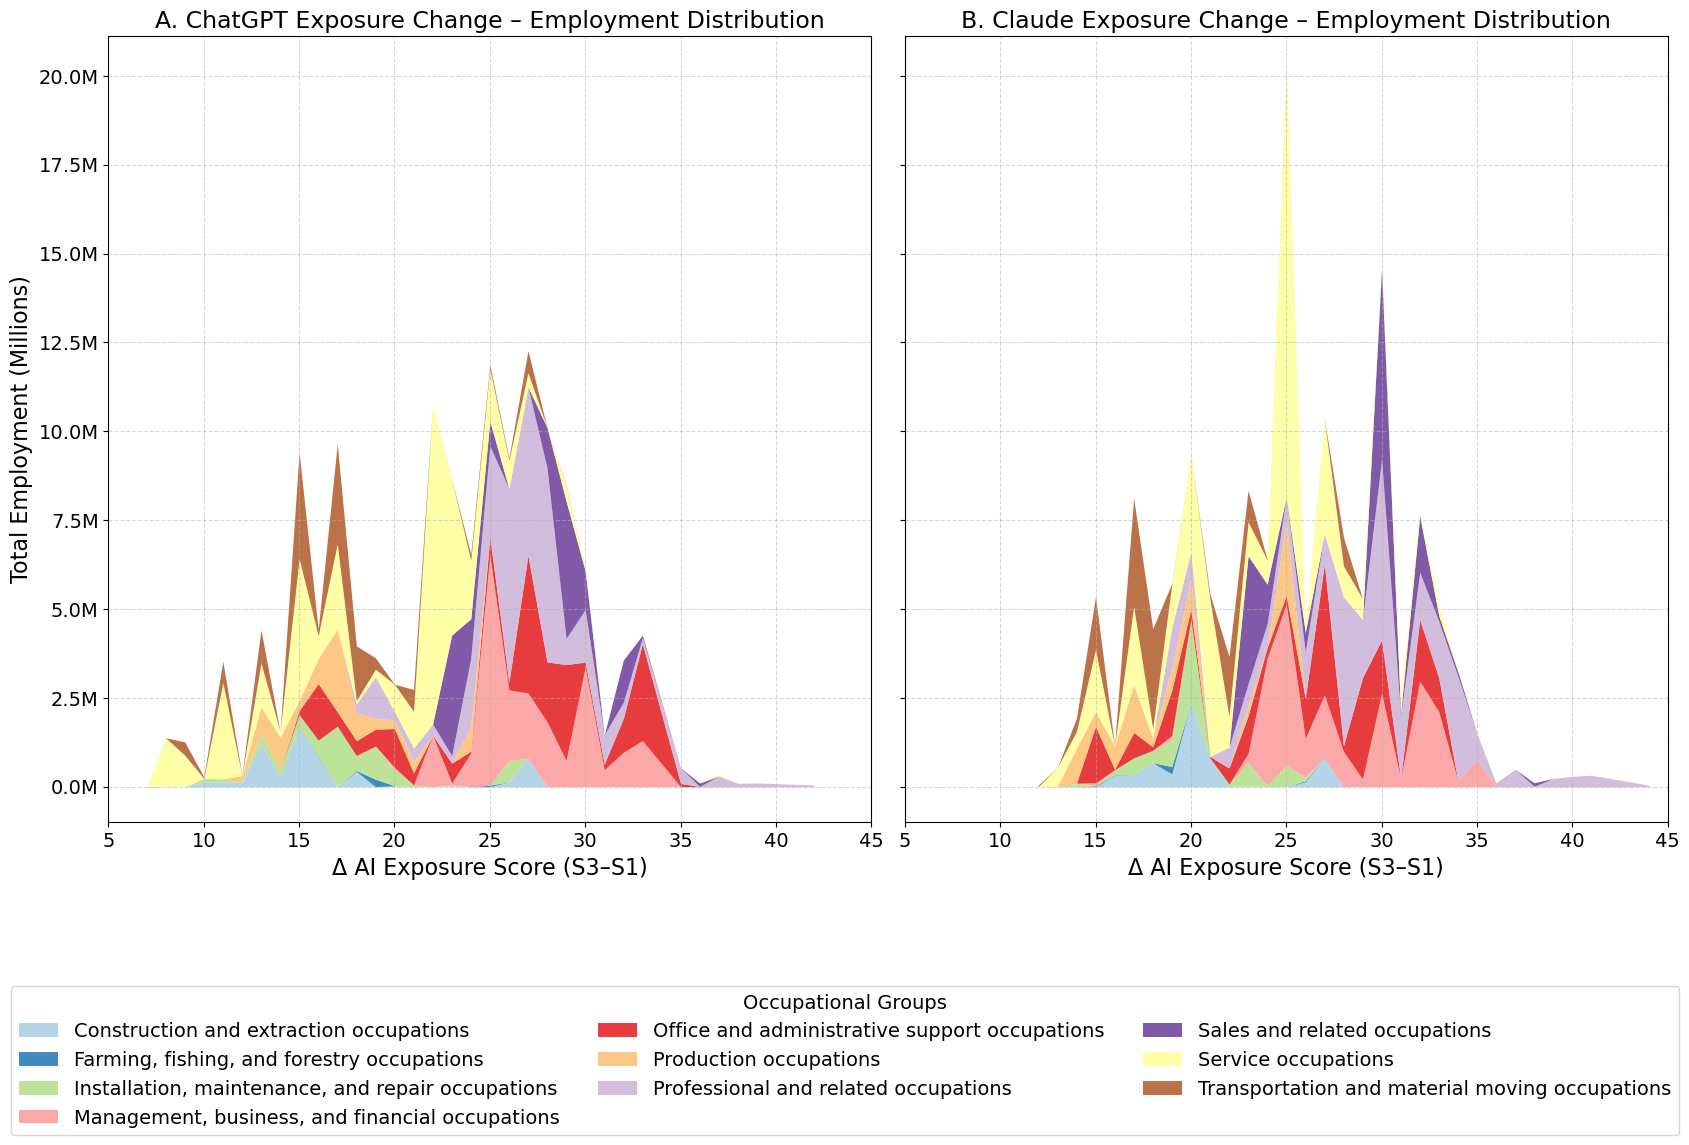

In [276]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

# Load the dataset
df = pd.read_stata("/Users/jdomins2/Desktop/CPS_Work/Data/Cleaned/oews_analysis.dta")

# Census occupation group mapping
group_map = {
    'Management, business, and financial occupations': range(10, 961),
    'Professional and related occupations': range(1005, 3551),
    'Service occupations': range(3601, 4656),
    'Sales and related occupations': range(4700, 4966),
    'Office and administrative support occupations': range(5000, 5941),
    'Farming, fishing, and forestry occupations': range(6005, 6131),
    'Construction and extraction occupations': range(6200, 6951),
    'Installation, maintenance, and repair occupations': range(7000, 7641),
    'Production occupations': range(7700, 8991),
    'Transportation and material moving occupations': range(9005, 9761),
    'Armed Forces': range(9840, 9841)
}
def assign_group(code):
    for group, code_range in group_map.items():
        if int(code) in code_range:
            return group
    return 'Unclassified'

df["group"] = df["cps_code"].apply(assign_group)

# Bin setup
bins = np.arange(5, 46, 1)

# Function to compute employment distribution
def get_emp_dist(df, exposure_col):
    df_sub = df.dropna(subset=[exposure_col, "group"]).copy()
    df_sub["exposure_bin"] = pd.cut(df_sub[exposure_col], bins=bins, labels=bins[:-1], include_lowest=True)
    dist = df_sub.groupby(["exposure_bin", "group"], observed=True)["tot_emp_24"].sum().unstack(fill_value=0)
    dist.index = dist.index.astype(int)
    return dist.sort_index()

emp_openai = get_emp_dist(df, "d_openai_S3_S1")
emp_claude = get_emp_dist(df, "d_claude_S3_S1")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(17, 10), sharey=True)
colors = plt.cm.Paired.colors

# Panel A: OpenAI
emp_openai.plot(kind="area", stacked=True, colormap="Paired", alpha=0.85, linewidth=0, ax=axes[0], legend=False)
axes[0].set_title("A. ChatGPT Exposure Change – Employment Distribution", fontsize=17)
axes[0].set_xlabel("Δ AI Exposure Score (S3–S1)", fontsize=16)
axes[0].set_ylabel("Total Employment (Millions)", fontsize=16)
axes[0].set_xlim(5, 45)
axes[0].grid(True, linestyle="--", alpha=0.5)

# Panel B: Claude
emp_claude.plot(kind="area", stacked=True, colormap="Paired", alpha=0.85, linewidth=0, ax=axes[1], legend=False)
axes[1].set_title("B. Claude Exposure Change – Employment Distribution", fontsize=17)
axes[1].set_xlabel("Δ AI Exposure Score (S3–S1)", fontsize=16)
axes[1].set_xlim(5, 45)
axes[1].grid(True, linestyle="--", alpha=0.5)

# Format y-axis in millions
for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x / 1e6:.1f}M'))
    ax.tick_params(axis='y', labelsize=14)
    ax.tick_params(axis='x', labelsize=14)  


# Shared Legend
handles, labels = axes[0].get_legend_handles_labels()

box = axes[0].get_position()

fig.legend(
    handles, labels,
    title="Occupational Groups",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.15),
    bbox_transform=fig.transFigure,
    ncol=3,
    fontsize=14,
    title_fontsize=14,
)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.savefig("Output/June/python/combined_emp_exp.png", dpi=300, bbox_inches="tight")
plt.show()


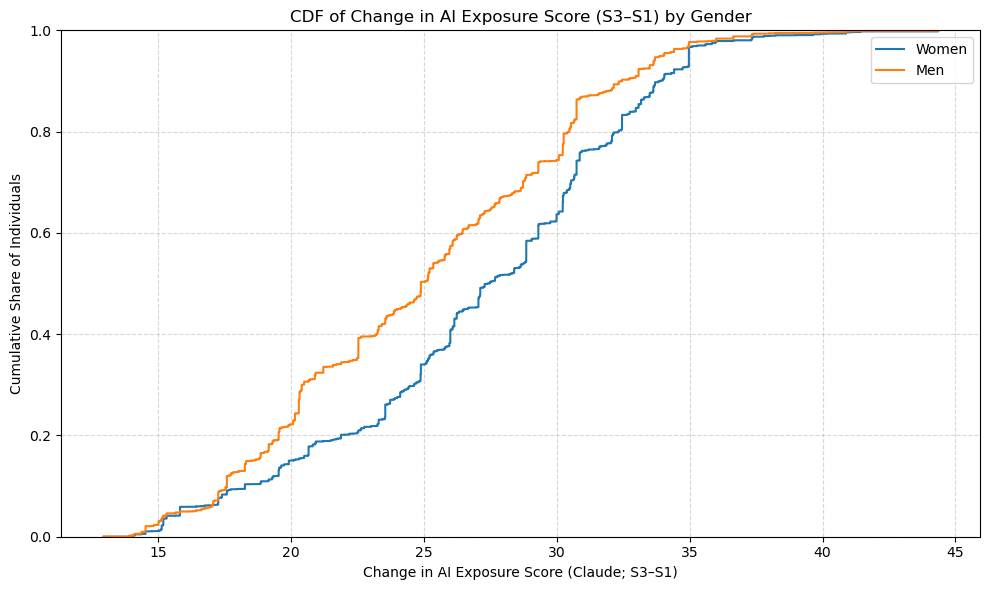

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop missing values
df = df.dropna(subset=["d_claude_S3_S1", "Dfem", "wtfinl"])

# Create CDF plot
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=df[df["Dfem"] == 1], x="d_claude_S3_S1", label="Women", weights=df[df["Dfem"] == 1]["wtfinl"])
sns.ecdfplot(data=df[df["Dfem"] == 0], x="d_claude_S3_S1", label="Men", weights=df[df["Dfem"] == 0]["wtfinl"])

plt.title("CDF of Change in AI Exposure Score (S3–S1) by Gender")
plt.xlabel("Change in AI Exposure Score (Claude; S3–S1)")
plt.ylabel("Cumulative Share of Individuals")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Output/June/python/cdf_exposure_gender_claude.png", dpi=300)
plt.show()


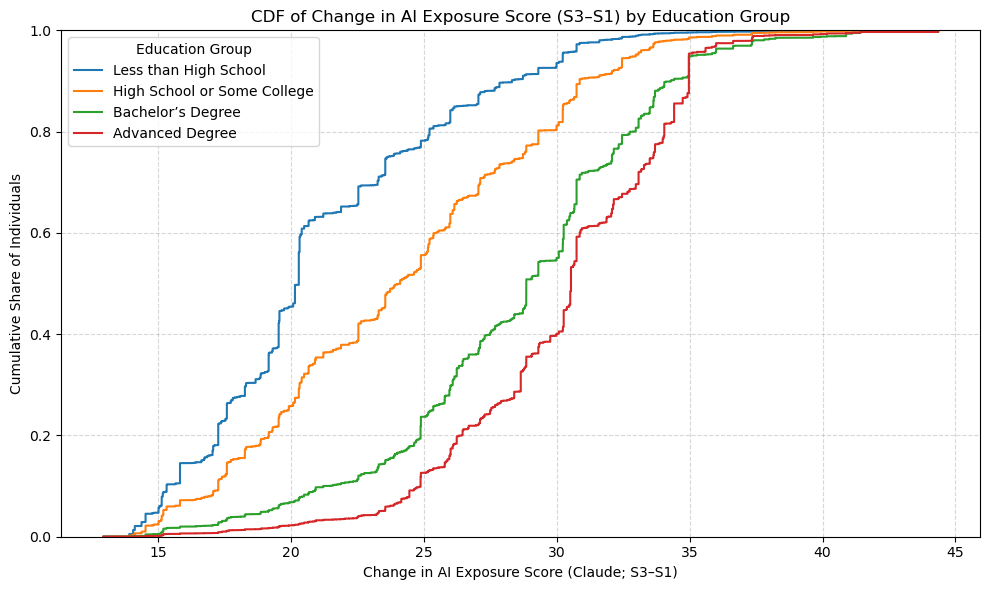

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop missing values
df = df.dropna(subset=["d_claude_S3_S1", "wtfinl", "educ_q1", "educ_q2", "educ_q3", "educ_q4"])

# Set up the plot
plt.figure(figsize=(10, 6))

# Define group labels and colors (optional)
educ_groups = {
    "Less than High School": "educ_q1",
    "High School or Some College": "educ_q2",
    "Bachelor’s Degree": "educ_q3",
    "Advanced Degree": "educ_q4"
}

# Plot CDF for each education group
for label, col in educ_groups.items():
    subset = df[df[col] == 1]
    sns.ecdfplot(data=subset, x="d_claude_S3_S1", weights=subset["wtfinl"], label=label)

# Final formatting
plt.title("CDF of Change in AI Exposure Score (S3–S1) by Education Group")
plt.xlabel("Change in AI Exposure Score (Claude; S3–S1)")
plt.ylabel("Cumulative Share of Individuals")
plt.legend(title="Education Group")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Output/June/python/cdf_exposure_education_claude.png", dpi=300)
plt.show()


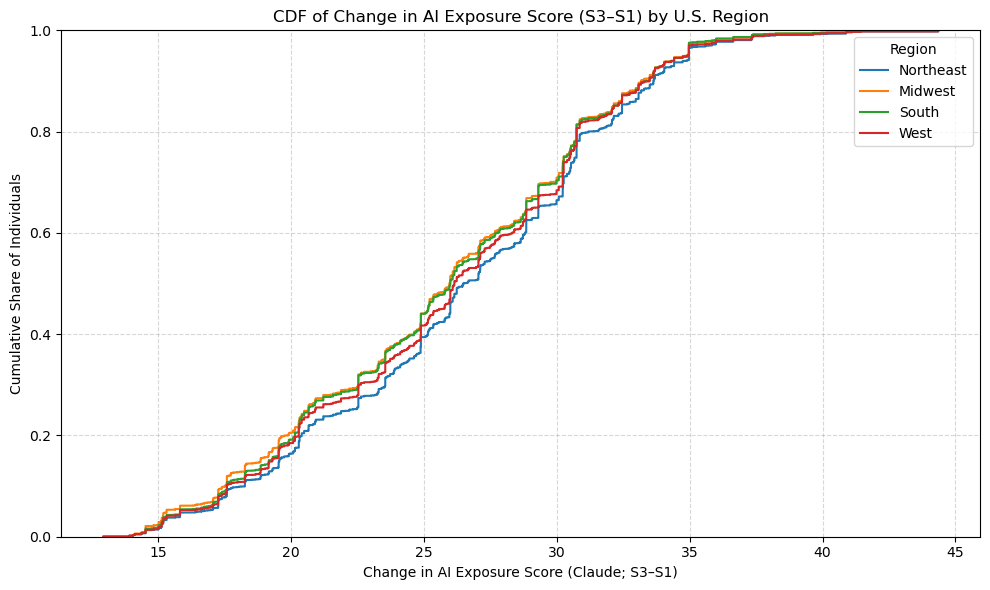

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop missing values
df = df.dropna(subset=["d_claude_S3_S1", "wtfinl", "d_northeast", "d_midwest", "d_south", "d_west"])

# Set up the plot
plt.figure(figsize=(10, 6))

# Define group labels and dummy variable names
region_groups = {
    "Northeast": "d_northeast",
    "Midwest": "d_midwest",
    "South": "d_south",
    "West": "d_west"
}

# Plot CDF for each region
for label, col in region_groups.items():
    subset = df[df[col] == 1]
    sns.ecdfplot(data=subset, x="d_claude_S3_S1", weights=subset["wtfinl"], label=label)

# Final formatting
plt.title("CDF of Change in AI Exposure Score (S3–S1) by U.S. Region")
plt.xlabel("Change in AI Exposure Score (Claude; S3–S1)")
plt.ylabel("Cumulative Share of Individuals")
plt.legend(title="Region")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Output/June/python/cdf_exposure_region_claude.png", dpi=300)
plt.show()


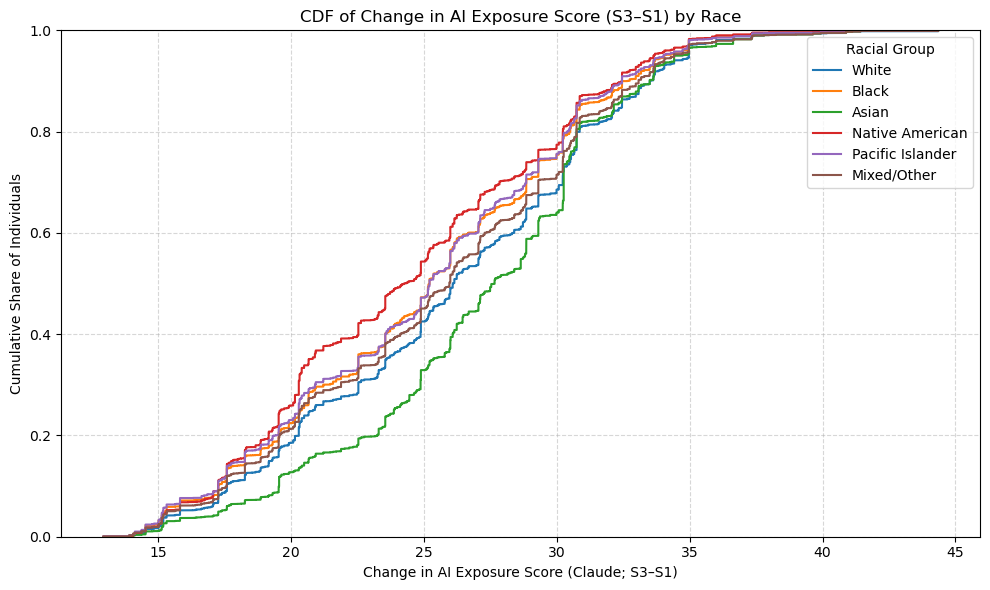

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop rows with missing values
df = df.dropna(subset=[
    "d_claude_S3_S1", "wtfinl",
    "race_white", "race_black", "race_asian",
    "race_native", "race_pacific", "race_mixed_other"
])

# Define racial group labels and their corresponding dummy variable names
race_groups = {
    "White": "race_white",
    "Black": "race_black",
    "Asian": "race_asian",
    "Native American": "race_native",
    "Pacific Islander": "race_pacific",
    "Mixed/Other": "race_mixed_other"
}

# Plot setup
plt.figure(figsize=(10, 6))

# Plot CDFs
for label, col in race_groups.items():
    subset = df[df[col] == 1]
    sns.ecdfplot(data=subset, x="d_claude_S3_S1", weights=subset["wtfinl"], label=label)

# Final formatting
plt.title("CDF of Change in AI Exposure Score (S3–S1) by Race")
plt.xlabel("Change in AI Exposure Score (Claude; S3–S1)")
plt.ylabel("Cumulative Share of Individuals")
plt.legend(title="Racial Group")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Output/June/python/cdf_exposure_race_claude.png", dpi=300)
plt.show()


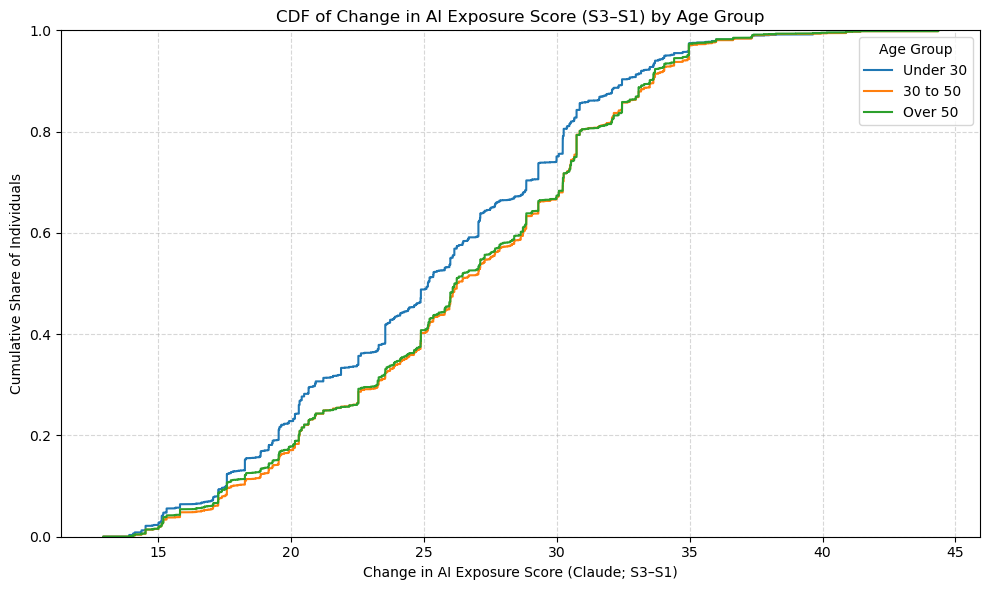

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/cps_for_analysis_march25.dta")

# Drop missing values for exposure, weights, and age group dummies
df = df.dropna(subset=["d_claude_S3_S1", "wtfinl", "age_30less", "age_30to50", "age_50plus"])

# ---------------- CDF Plot ----------------
plt.figure(figsize=(10, 6))

age_groups = {
    "Under 30": "age_30less",
    "30 to 50": "age_30to50",
    "Over 50": "age_50plus"
}

for label, col in age_groups.items():
    subset = df[df[col] == 1]
    sns.ecdfplot(data=subset, x="d_claude_S3_S1", weights=subset["wtfinl"], label=label)

plt.title("CDF of Change in AI Exposure Score (S3–S1) by Age Group")
plt.xlabel("Change in AI Exposure Score (Claude; S3–S1)")
plt.ylabel("Cumulative Share of Individuals")
plt.legend(title="Age Group")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("Output/June/python/cdf_exposure_agegroup_claude.png", dpi=300)
plt.show()

[PROCESSING] Software developers


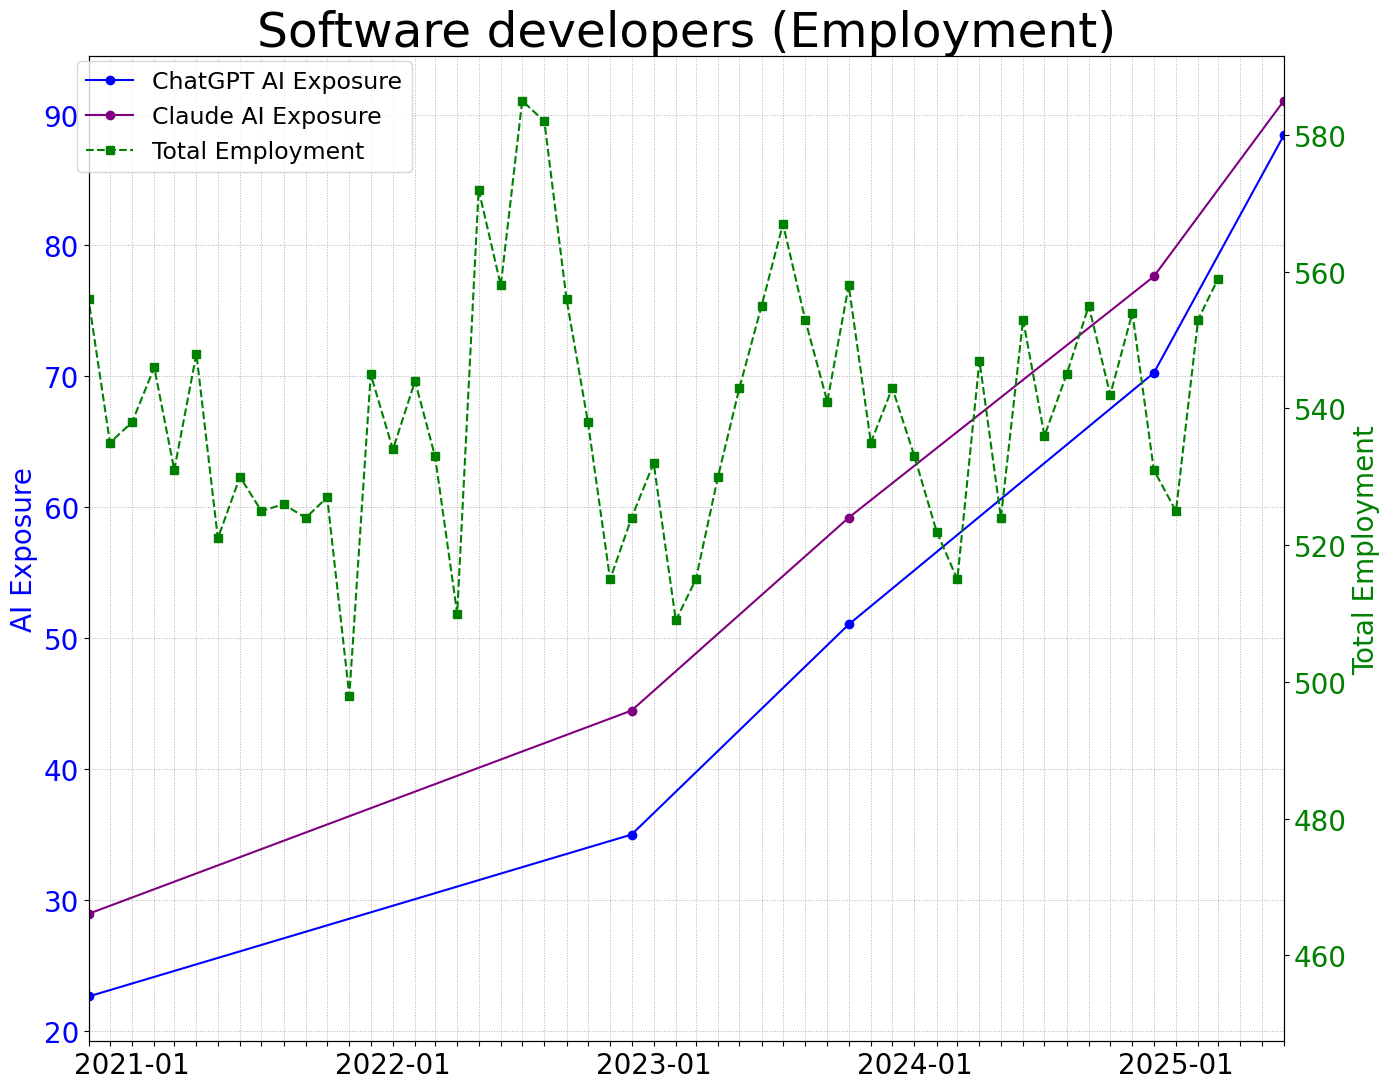

[SAVED] Output/June/python/software_developers_emp.png


In [248]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime

# Load updated dataset
df = pd.read_stata("Data/Cleaned/monthly_cps_by_occ_march25.dta")
df["cps_code"] = df["cps_code"].astype(str)

# Fix month formatting
month_str_to_num = {
    "january": "01", "february": "02", "march": "03", "april": "04",
    "may": "05", "june": "06", "july": "07", "august": "08",
    "september": "09", "october": "10", "november": "11", "december": "12"
}
df["month"] = df["month"].astype(str).str.lower().map(month_str_to_num).fillna(df["month"])
df["month"] = df["month"].astype(str).str.zfill(2)
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"] + "-01", format="%Y-%m-%d")

# Filter for software developers
code = "1021"
title = "Software developers"
df_occ = df[df["cps_code"] == code].copy()

# Calculate standard errors and 95% CI using Poisson approximation
df_occ["se"] = np.sqrt(df_occ["demployed"])
df_occ["ci_lower"] = df_occ["demployed"] - 1.96 * df_occ["se"]
df_occ["ci_upper"] = df_occ["demployed"] + 1.96 * df_occ["se"]

# Confirm non-empty
if df_occ.empty:
    print(f"[SKIP] No data for {title}")
else:
    print(f"[PROCESSING] {title}")
    fig, ax1 = plt.subplots(figsize=(14, 11))
    ax1.grid(True, linestyle=':', linewidth=0.7)

    # Define stage boundaries
    stage_dates = [
        datetime(2020, 11, 1),
        datetime(2022, 12, 1),
        datetime(2023, 10, 1),
        datetime(2024, 12, 1),
        datetime(2025, 6, 1)
    ]
    exposures = [
        df_occ["openai1"].iloc[0],
        df_occ["openai2"].iloc[0],
        df_occ["openai3"].iloc[0],
        df_occ["openai4"].iloc[0],
        df_occ["openai5"].iloc[0]
    ]
    claude_exposures = [
        df_occ["claude1"].iloc[0],
        df_occ["claude2"].iloc[0],
        df_occ["claude3"].iloc[0],
        df_occ["claude4"].iloc[0],
        df_occ["claude5"].iloc[0]
    ]

    # AI Exposure
    ax1.plot(stage_dates, exposures, color='blue', linestyle='-', marker='o', label="ChatGPT AI Exposure")
    ax1.plot(stage_dates, claude_exposures, color='purple', linestyle='-', marker='o', label="Claude AI Exposure")
    ax1.set_ylabel("AI Exposure", color='blue', fontsize=20)
    ax1.tick_params(axis='y', labelcolor='blue', labelsize=20)

    # Employment
    ax2 = ax1.twinx()
    ax2.plot(df_occ["date"], df_occ["demployed"], color='green', linestyle='--', marker='s', label="Total Employment")
    # ax2.fill_between(df_occ["date"], df_occ["ci_lower"], df_occ["ci_upper"], color='green', alpha=0.2, label="95% CI")
    ax2.set_ylabel("Total Employment", color='green', fontsize=20)
    ax2.tick_params(axis='y', labelcolor='green', labelsize=20)
    ax2.grid(False)

    # Format x-axis to only label January
    ax1.set_xlim(datetime(2020, 11, 1), datetime(2025, 6, 1))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    for label in ax1.get_xticklabels():
        try:
            month = pd.to_datetime(label.get_text(), format='%Y-%m').month
            if month != 1:
                label.set_visible(False)
            else:
                label.set_text(label.get_text()[:4])
        except:
            label.set_visible(False)

    plt.setp(ax1.get_xticklabels(), rotation=0, ha='center', fontsize=20)

    # Title and legend
    plt.title(f"{title} (Employment)", fontsize=35)
    fig.legend(loc="upper left", bbox_to_anchor=(0.05, 0.95), fontsize=17)
    plt.tight_layout()

    # Save
    output_dir = "Output/June/python"
    os.makedirs(output_dir, exist_ok=True)
    filename = f"{output_dir}/software_developers_emp.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[SAVED] {filename}")


[PROCESSING] Software developers


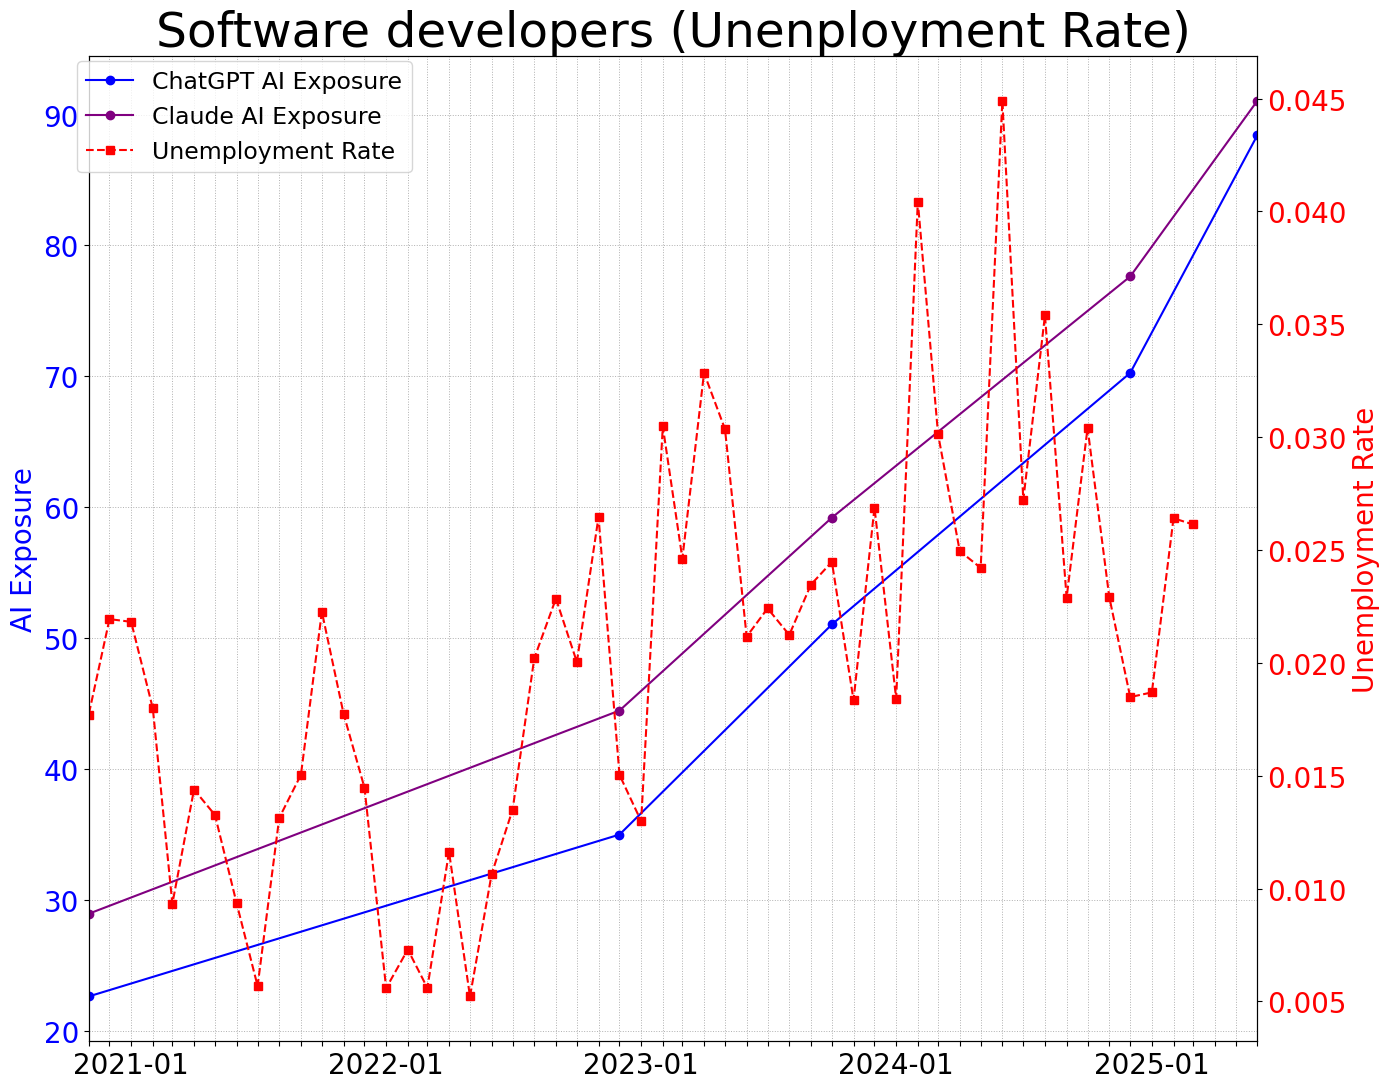

[SAVED] Output/June/python/software_developers_unemp.png


In [250]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime
import numpy as np

# Load updated dataset
df = pd.read_stata("Data/Cleaned/monthly_cps_by_occ_march25.dta")
df["cps_code"] = df["cps_code"].astype(str)

# Fix month formatting
month_str_to_num = {
    "january": "01", "february": "02", "march": "03", "april": "04",
    "may": "05", "june": "06", "july": "07", "august": "08",
    "september": "09", "october": "10", "november": "11", "december": "12"
}
df["month"] = df["month"].astype(str).str.lower().map(month_str_to_num).fillna(df["month"])
df["month"] = df["month"].astype(str).str.zfill(2)
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"] + "-01", format="%Y-%m-%d")

# Filter for software developers
code = "1021"
title = "Software developers"
df_occ = df[df["cps_code"] == code].copy()

# Calculate standard errors and 95% CI for unemp_rate (proportion)
df_occ["se"] = np.sqrt(df_occ["unemp_rate"] * (1 - df_occ["unemp_rate"]) / df_occ["n_obs"])
df_occ["ci_lower"] = df_occ["unemp_rate"] - 1.96 * df_occ["se"]
df_occ["ci_upper"] = df_occ["unemp_rate"] + 1.96 * df_occ["se"]

# Confirm non-empty
if df_occ.empty:
    print(f"[SKIP] No data for {title}")
else:
    print(f"[PROCESSING] {title}")
    fig, ax1 = plt.subplots(figsize=(14, 11))
    ax1.grid(True, linestyle=':', linewidth=0.7)

    # Exposure stages
    stage_dates = [
        datetime(2020, 11, 1),
        datetime(2022, 12, 1),
        datetime(2023, 10, 1),
        datetime(2024, 12, 1),
        datetime(2025, 6, 1)
    ]
    exposures = [
        df_occ["openai1"].iloc[0],
        df_occ["openai2"].iloc[0],
        df_occ["openai3"].iloc[0],
        df_occ["openai4"].iloc[0],
        df_occ["openai5"].iloc[0]
    ]
    
    claude_exposures = [
        df_occ["claude1"].iloc[0],
        df_occ["claude2"].iloc[0],
        df_occ["claude3"].iloc[0],
        df_occ["claude4"].iloc[0],
        df_occ["claude5"].iloc[0]
    ]

    # Exposure line
    ax1.plot(stage_dates, exposures, color='blue', linestyle='-', marker='o', label="ChatGPT AI Exposure")
    ax1.plot(stage_dates, claude_exposures, color='purple', linestyle='-', marker='o', label="Claude AI Exposure")
    ax1.set_ylabel("AI Exposure", color='blue', fontsize=20)
    ax1.tick_params(axis='y', labelcolor='blue', labelsize=20)

    # Unemployment rate + CI band
    ax2 = ax1.twinx()
    ax2.plot(df_occ["date"], df_occ["unemp_rate"], color='red', linestyle='--', marker='s', label="Unemployment Rate")
    # ax2.fill_between(df_occ["date"], df_occ["ci_lower"], df_occ["ci_upper"], color='red', alpha=0.2, label="95% CI")
    ax2.set_ylabel("Unemployment Rate", color='red', fontsize=20)
    ax2.tick_params(axis='y', labelcolor='red', labelsize=20)
    ax2.grid(False)

    # X-axis formatting
    ax1.set_xlim(datetime(2020, 11, 1), datetime(2025, 6, 1))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    for label in ax1.get_xticklabels():
        try:
            month = pd.to_datetime(label.get_text(), format='%Y-%m').month
            if month != 1:
                label.set_visible(False)
            else:
                label.set_text(label.get_text()[:4])
        except:
            label.set_visible(False)

    plt.setp(ax1.get_xticklabels(), rotation=0, ha='center', fontsize=20)

    # Title and legend
    plt.title(f"{title} (Unenployment Rate)", fontsize=35)
    fig.legend(loc="upper left", bbox_to_anchor=(0.05, 0.95), fontsize=17)
    plt.tight_layout()

    # Save
    output_dir = "Output/June/python"
    os.makedirs(output_dir, exist_ok=True)
    filename = f"{output_dir}/software_developers_unemp.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[SAVED] {filename}")


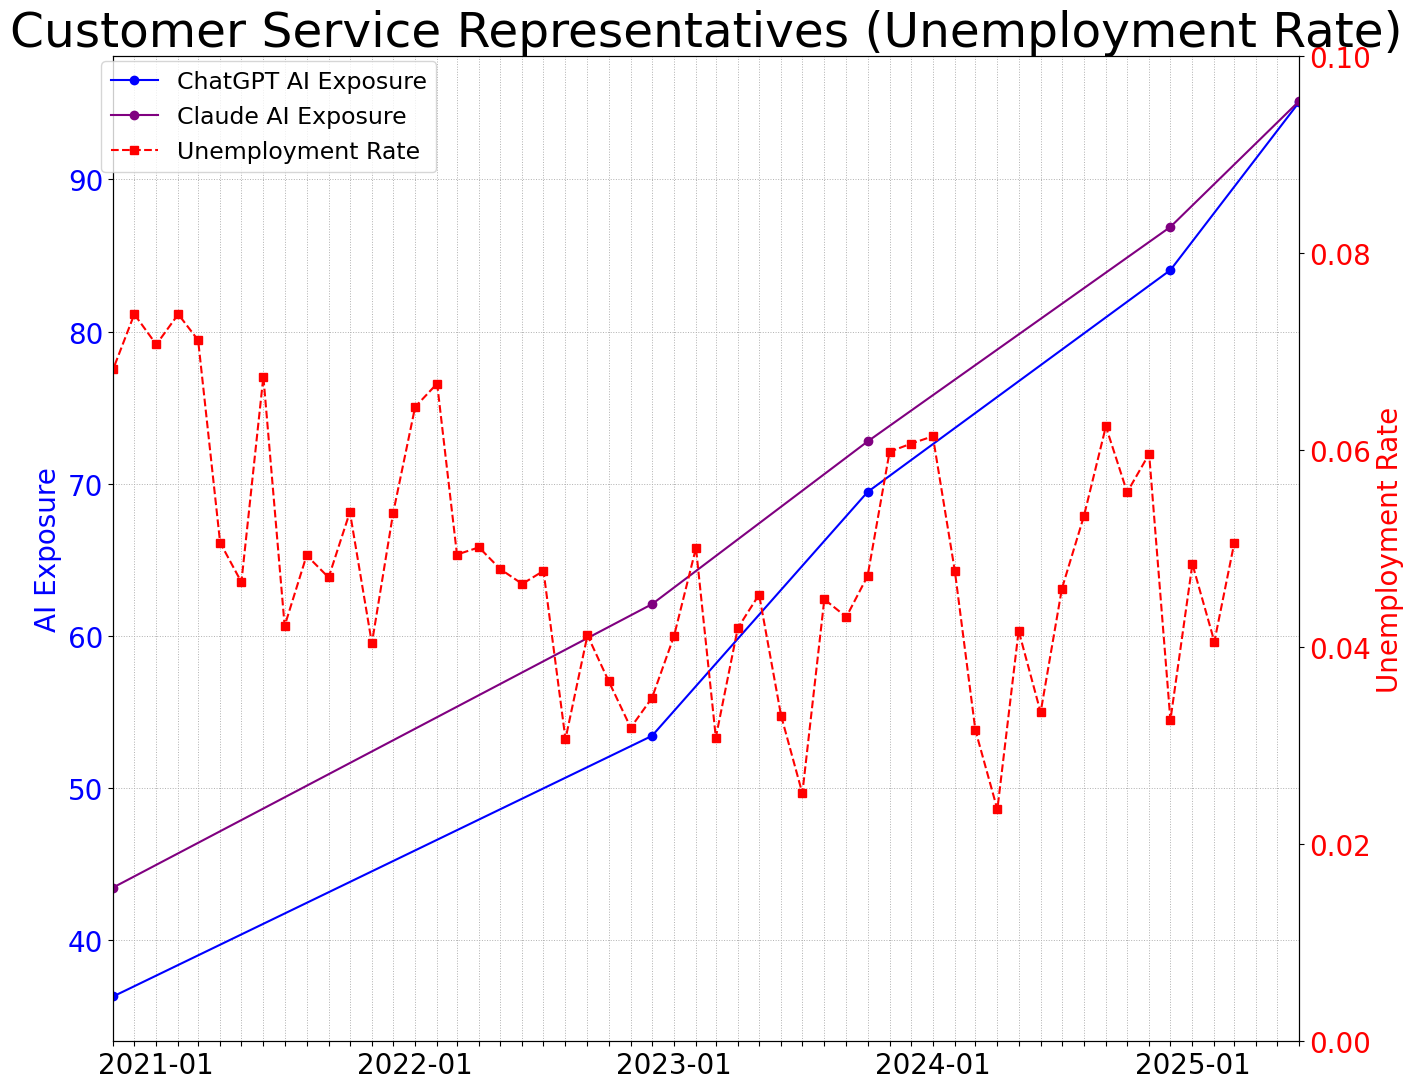

[SAVED] Output/June/python/customer_service_unemp.png


In [252]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/monthly_cps_by_occ_march25.dta")
df["cps_code"] = df["cps_code"].astype(str)

# Format month and date
month_str_to_num = {
    "january": "01", "february": "02", "march": "03", "april": "04",
    "may": "05", "june": "06", "july": "07", "august": "08",
    "september": "09", "october": "10", "november": "11", "december": "12"
}
df["month"] = df["month"].astype(str).str.lower().map(month_str_to_num).fillna(df["month"])
df["month"] = df["month"].astype(str).str.zfill(2)
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"] + "-01", format="%Y-%m-%d")

# Define a reusable function for plotting
def plot_unemp_with_exposure(code, title, save_path):
    df_occ = df[df["cps_code"] == code].copy()
    if df_occ.empty:
        print(f"[SKIP] No data for {title}")
        return

    # Compute 95% CI for unemployment rate
    df_occ["se"] = np.sqrt(df_occ["unemp_rate"] * (1 - df_occ["unemp_rate"]) / df_occ["n_obs"])
    df_occ["ci_lower"] = df_occ["unemp_rate"] - 1.96 * df_occ["se"]
    df_occ["ci_upper"] = df_occ["unemp_rate"] + 1.96 * df_occ["se"]

    # Stage boundaries and exposure values
    stage_dates = [
        datetime(2020, 11, 1),
        datetime(2022, 12, 1),
        datetime(2023, 10, 1),
        datetime(2024, 12, 1),
        datetime(2025, 6, 1)
    ]
    exposures = [
        df_occ["openai1"].iloc[0],
        df_occ["openai2"].iloc[0],
        df_occ["openai3"].iloc[0],
        df_occ["openai4"].iloc[0],
        df_occ["openai5"].iloc[0]
    ]

    claude_exposures = [
        df_occ["claude1"].iloc[0],
        df_occ["claude2"].iloc[0],
        df_occ["claude3"].iloc[0],
        df_occ["claude4"].iloc[0],
        df_occ["claude5"].iloc[0]
    ]

    # Plot
    fig, ax1 = plt.subplots(figsize=(14, 11))
    ax1.grid(True, linestyle=':', linewidth=0.7)

    # Exposure line
    ax1.plot(stage_dates, exposures, color='blue', linestyle='-', marker='o', label="ChatGPT AI Exposure")
    ax1.plot(stage_dates, claude_exposures, color='purple', linestyle='-', marker='o', label="Claude AI Exposure")
    ax1.set_ylabel("AI Exposure", color='blue', fontsize=20)
    ax1.tick_params(axis='y', labelcolor='blue', labelsize=20)

    ax2 = ax1.twinx()
    ax2.plot(df_occ["date"], df_occ["unemp_rate"], color='red', linestyle='--', marker='s', label="Unemployment Rate")
    # ax2.fill_between(df_occ["date"], df_occ["ci_lower"], df_occ["ci_upper"], color='red', alpha=0.2, label="95% CI")
    ax2.set_ylabel("Unemployment Rate", color='red', fontsize=20)
    ax2.tick_params(axis='y', labelcolor='red', labelsize=20)
    ax2.grid(False)
    ax2.set_ylim(0, 0.1)

    # X-axis formatting
    ax1.set_xlim(datetime(2020, 11, 1), datetime(2025, 6, 1))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    for label in ax1.get_xticklabels():
        try:
            month = pd.to_datetime(label.get_text(), format='%Y-%m').month
            if month != 1:
                label.set_visible(False)
            else:
                label.set_text(label.get_text()[:4])
        except:
            label.set_visible(False)
    plt.setp(ax1.get_xticklabels(), rotation=0, ha='center', fontsize=20)

    plt.title(f"{title} (Unemployment Rate)", fontsize=35)
    fig.legend(loc="upper left", bbox_to_anchor=(0.05, 0.95), fontsize=17)
    plt.tight_layout()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[SAVED] {save_path}")

# Run for Customer Service Representatives
plot_unemp_with_exposure(code="5240", title="Customer Service Representatives",
                         save_path="Output/June/python/customer_service_unemp.png")


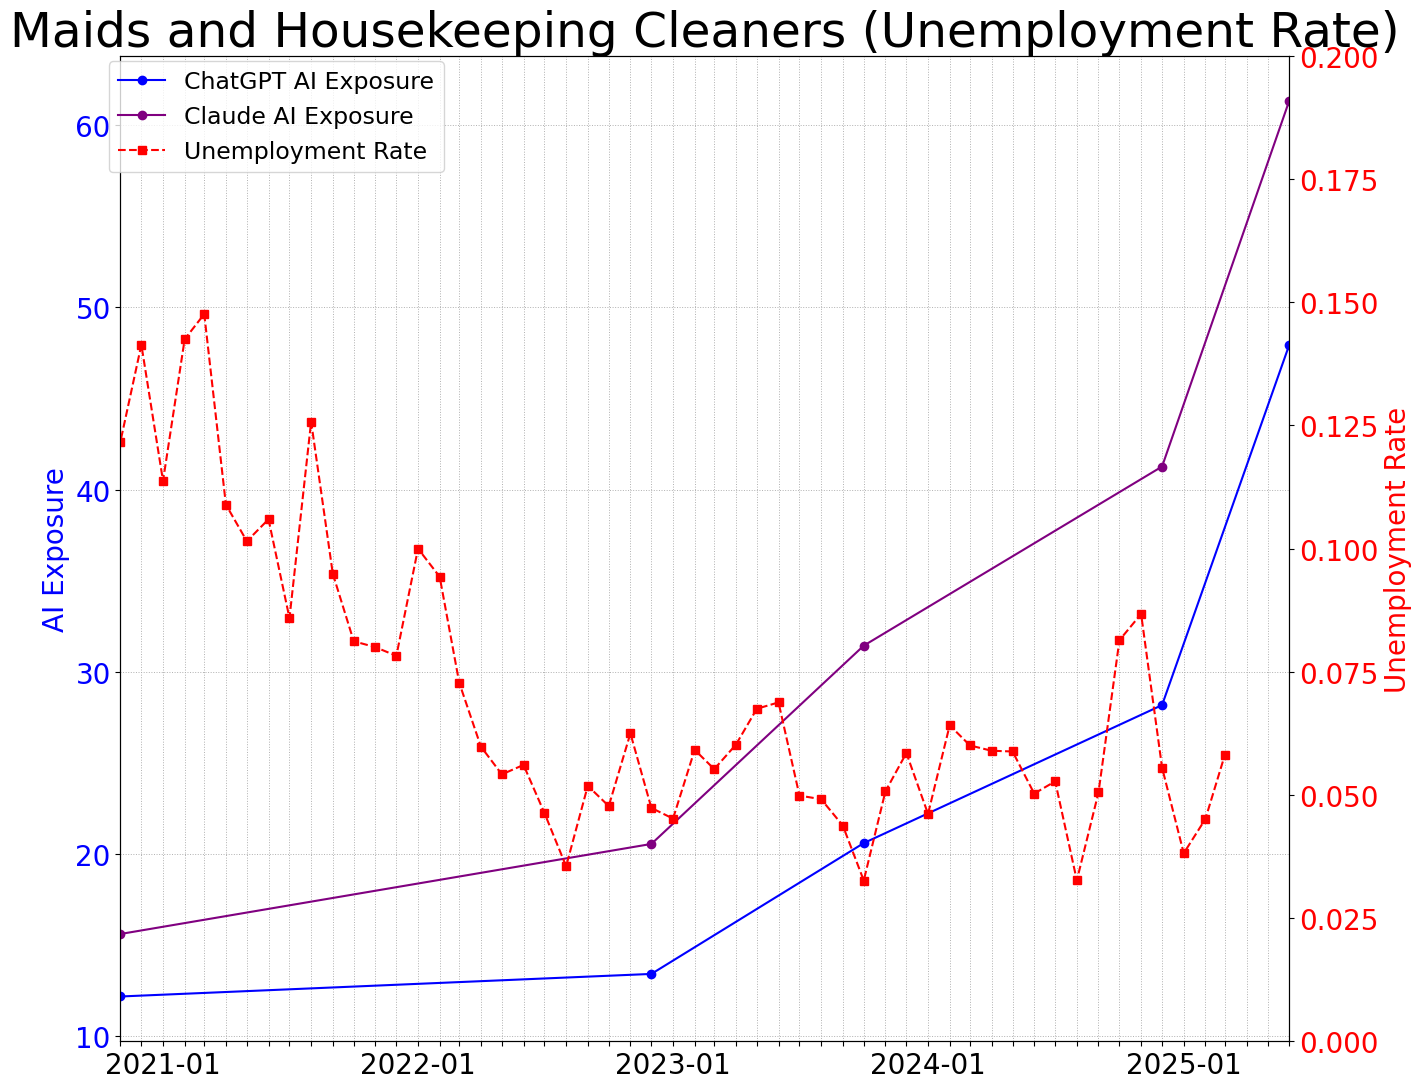

[SAVED] Output/June/python/maids_housekeeping_unemp.png


In [254]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
from datetime import datetime
import numpy as np

# Load data
df = pd.read_stata("Data/Cleaned/monthly_cps_by_occ_march25.dta")
df["cps_code"] = df["cps_code"].astype(str)

# Format month and date
month_str_to_num = {
    "january": "01", "february": "02", "march": "03", "april": "04",
    "may": "05", "june": "06", "july": "07", "august": "08",
    "september": "09", "october": "10", "november": "11", "december": "12"
}
df["month"] = df["month"].astype(str).str.lower().map(month_str_to_num).fillna(df["month"])
df["month"] = df["month"].astype(str).str.zfill(2)
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"] + "-01", format="%Y-%m-%d")

# Define a reusable function for plotting
def plot_unemp_with_exposure(code, title, save_path):
    df_occ = df[df["cps_code"] == code].copy()
    if df_occ.empty:
        print(f"[SKIP] No data for {title}")
        return

    # Compute 95% CI for unemployment rate
    df_occ["se"] = np.sqrt(df_occ["unemp_rate"] * (1 - df_occ["unemp_rate"]) / df_occ["n_obs"])
    df_occ["ci_lower"] = df_occ["unemp_rate"] - 1.96 * df_occ["se"]
    df_occ["ci_upper"] = df_occ["unemp_rate"] + 1.96 * df_occ["se"]

    # Stage boundaries and exposure values
    stage_dates = [
        datetime(2020, 11, 1),
        datetime(2022, 12, 1),
        datetime(2023, 10, 1),
        datetime(2024, 12, 1),
        datetime(2025, 6, 1)
    ]
    exposures = [
        df_occ["openai1"].iloc[0],
        df_occ["openai2"].iloc[0],
        df_occ["openai3"].iloc[0],
        df_occ["openai4"].iloc[0],
        df_occ["openai5"].iloc[0]
    ]

    claude_exposures = [
        df_occ["claude1"].iloc[0],
        df_occ["claude2"].iloc[0],
        df_occ["claude3"].iloc[0],
        df_occ["claude4"].iloc[0],
        df_occ["claude5"].iloc[0]
    ]

    # Plot
    fig, ax1 = plt.subplots(figsize=(14, 11))
    ax1.grid(True, linestyle=':', linewidth=0.7)

    # Exposure line
    ax1.plot(stage_dates, exposures, color='blue', linestyle='-', marker='o', label="ChatGPT AI Exposure")
    ax1.plot(stage_dates, claude_exposures, color='purple', linestyle='-', marker='o', label="Claude AI Exposure")
    ax1.set_ylabel("AI Exposure", color='blue', fontsize=20)
    ax1.tick_params(axis='y', labelcolor='blue', labelsize=20)

    # Unemployment line
    ax2 = ax1.twinx()
    ax2.plot(df_occ["date"], df_occ["unemp_rate"], color='red', linestyle='--', marker='s', label="Unemployment Rate")
    # ax2.fill_between(df_occ["date"], df_occ["ci_lower"], df_occ["ci_upper"], color='red', alpha=0.2, label="95% CI")
    ax2.set_ylabel("Unemployment Rate", color='red', fontsize=20)
    ax2.tick_params(axis='y', labelcolor='red', labelsize=20)
    ax2.grid(False)
    ax2.set_ylim(0, 0.2)

    # X-axis formatting
    ax1.set_xlim(datetime(2020, 11, 1), datetime(2025, 6, 1))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    for label in ax1.get_xticklabels():
        try:
            month = pd.to_datetime(label.get_text(), format='%Y-%m').month
            if month != 1:
                label.set_visible(False)
            else:
                label.set_text(label.get_text()[:4])
        except:
            label.set_visible(False)
    plt.setp(ax1.get_xticklabels(), rotation=0, ha='center', fontsize=20)

    plt.title(f"{title} (Unemployment Rate)", fontsize=35)
    fig.legend(loc="upper left", bbox_to_anchor=(0.05, 0.95), fontsize=17)
    plt.tight_layout()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[SAVED] {save_path}")

# Run for Maids and Housekeeping Cleaners
plot_unemp_with_exposure(code="4230", title="Maids and Housekeeping Cleaners",
                         save_path="Output/June/python/maids_housekeeping_unemp.png")


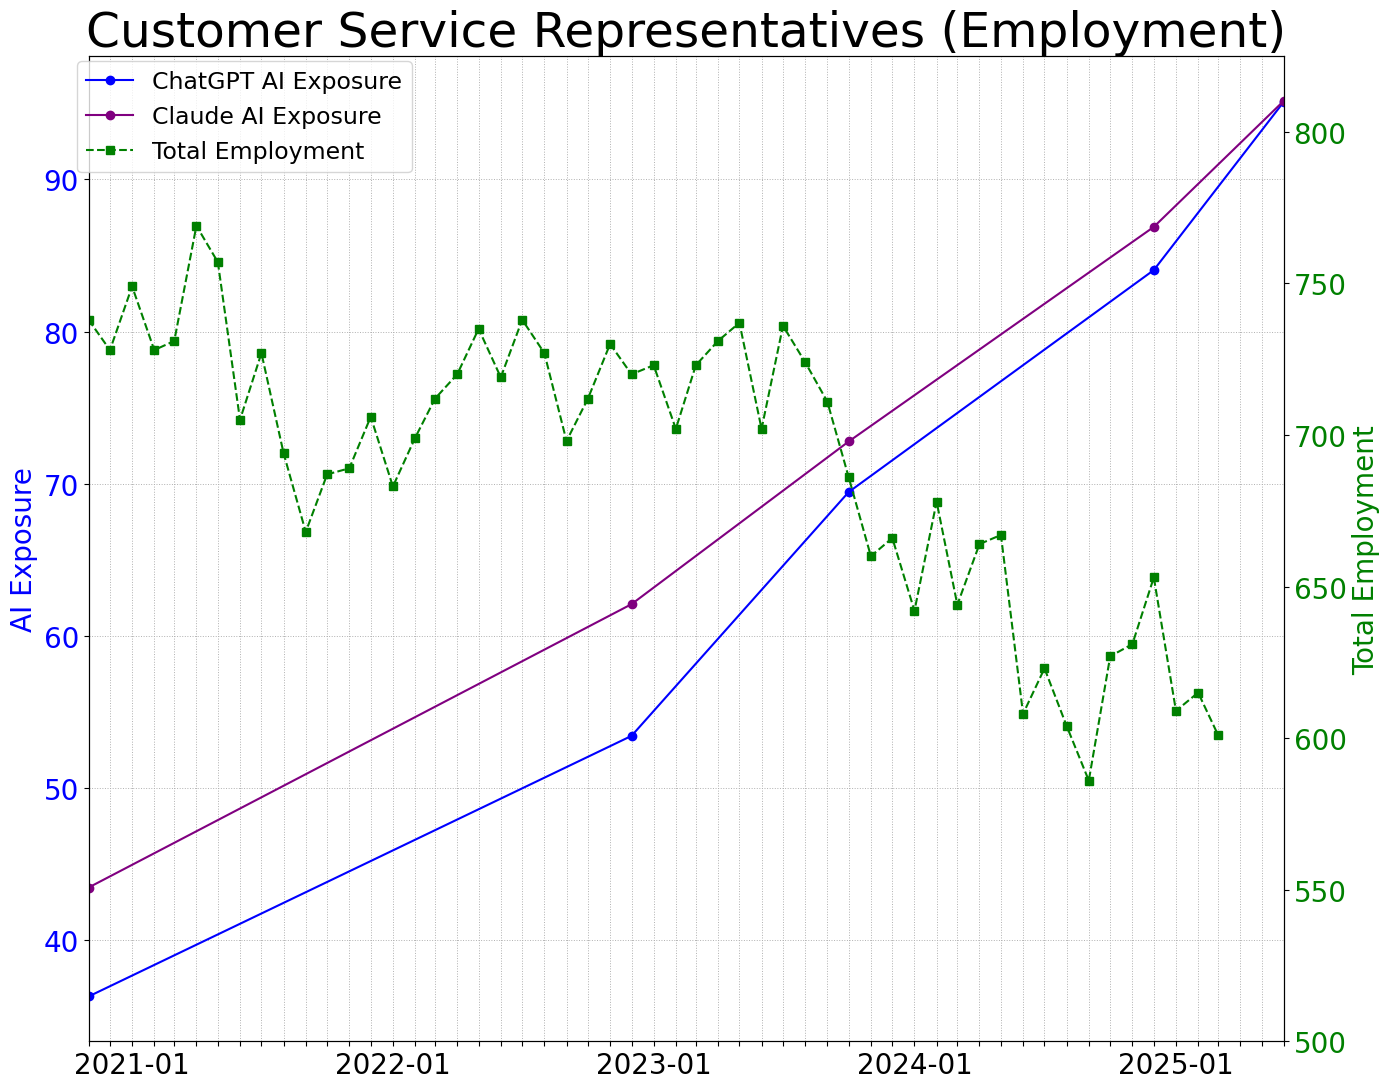

[SAVED] Output/June/python/csr_march2025.png


In [256]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import numpy as np
from datetime import datetime

# Load dataset
df = pd.read_stata("Data/Cleaned/monthly_cps_by_occ_march25.dta")
df["cps_code"] = df["cps_code"].astype(str)

# Fix month formatting
month_str_to_num = {
    "january": "01", "february": "02", "march": "03", "april": "04",
    "may": "05", "june": "06", "july": "07", "august": "08",
    "september": "09", "october": "10", "november": "11", "december": "12"
}
df["month"] = df["month"].astype(str).str.lower().map(month_str_to_num).fillna(df["month"])
df["month"] = df["month"].astype(str).str.zfill(2)
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"] + "-01", format="%Y-%m-%d")

# Plotting function
def plot_occ_emp(code, title, filename_out):
    df_occ = df[df["cps_code"] == code].copy()
    
    # Poisson CI
    df_occ["se"] = np.sqrt(df_occ["demployed"])
    df_occ["ci_lower"] = df_occ["demployed"] - 1.96 * df_occ["se"]
    df_occ["ci_upper"] = df_occ["demployed"] + 1.96 * df_occ["se"]
    
    if df_occ.empty:
        print(f"[SKIP] No data for {title}")
        return

    # Exposure timeline setup
    stage_dates = [
        datetime(2020, 11, 1),
        datetime(2022, 12, 1),
        datetime(2023, 10, 1),
        datetime(2024, 12, 1),
        datetime(2025, 6, 1)
    ]
    exposures = [
        df_occ["openai1"].iloc[0],
        df_occ["openai2"].iloc[0],
        df_occ["openai3"].iloc[0],
        df_occ["openai4"].iloc[0],
        df_occ["openai5"].iloc[0]
    ]

    claude_exposures = [
        df_occ["claude1"].iloc[0],
        df_occ["claude2"].iloc[0],
        df_occ["claude3"].iloc[0],
        df_occ["claude4"].iloc[0],
        df_occ["claude5"].iloc[0]
    ]

    # Plot
    fig, ax1 = plt.subplots(figsize=(14, 11))
    ax1.grid(True, linestyle=':', linewidth=0.7)

    ax1.plot(stage_dates, exposures, color='blue', linestyle='-', marker='o', label="ChatGPT AI Exposure")
    ax1.plot(stage_dates, claude_exposures, color='purple', linestyle='-', marker='o', label="Claude AI Exposure")
    ax1.set_ylabel("AI Exposure", color='blue', fontsize=20)
    ax1.tick_params(axis='y', labelcolor='blue', labelsize=20)

    ax2 = ax1.twinx()
    ax2.plot(df_occ["date"], df_occ["demployed"], color='green', linestyle='--', marker='s', label="Total Employment")
    # ax2.fill_between(df_occ["date"], df_occ["ci_lower"], df_occ["ci_upper"], color='green', alpha=0.2, label="95% CI")
    ax2.set_ylabel("Total Employment", color='green', fontsize=20)
    ax2.tick_params(axis='y', labelcolor='green', labelsize=20)
    ax2.grid(False)
    ax2.set_ylim(500, 825)

    ax1.set_xlim(datetime(2020, 11, 1), datetime(2025, 6, 1))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    for label in ax1.get_xticklabels():
        try:
            month = pd.to_datetime(label.get_text(), format='%Y-%m').month
            if month != 1:
                label.set_visible(False)
            else:
                label.set_text(label.get_text()[:4])
        except:
            label.set_visible(False)
    plt.setp(ax1.get_xticklabels(), rotation=0, ha='center', fontsize=20)

    plt.title(f"{title} (Employment)", fontsize=35)
    fig.legend(loc="upper left", bbox_to_anchor=(0.05, 0.95), fontsize=17)
    plt.tight_layout()

    output_dir = "Output/June/python"
    os.makedirs(output_dir, exist_ok=True)
    filename = f"{output_dir}/{filename_out}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[SAVED] {filename}")

# Call function for Customer Service Representatives
plot_occ_emp("5240", "Customer Service Representatives", "csr_march2025")


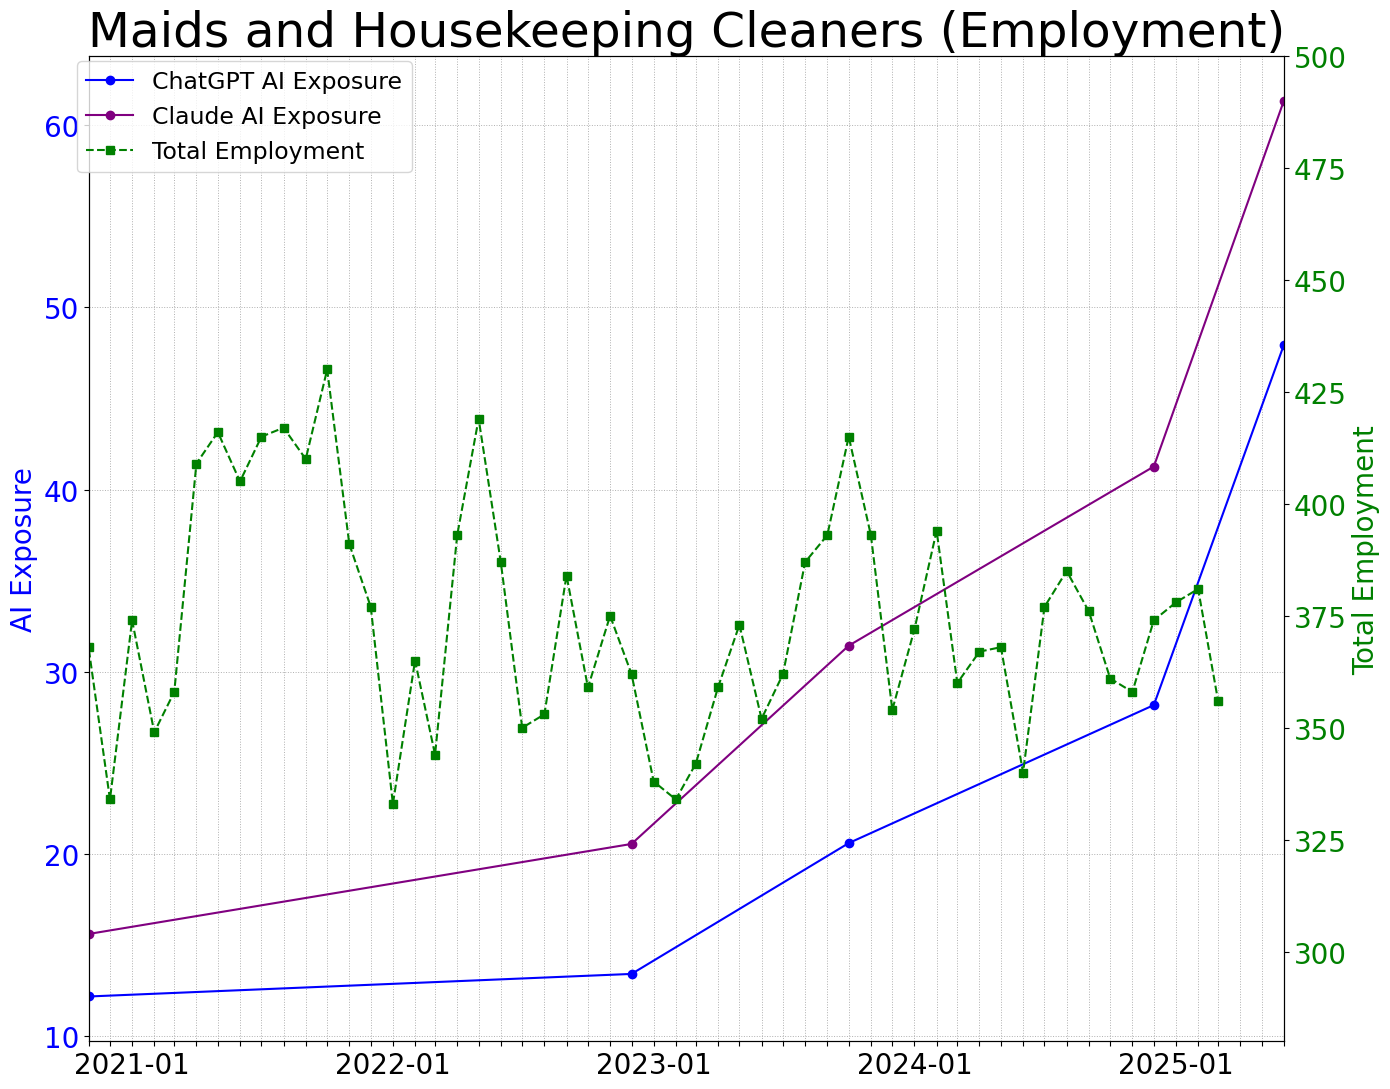

[SAVED] Output/June/python/maids_march2025.png


In [258]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import numpy as np
from datetime import datetime

# Load dataset
df = pd.read_stata("Data/Cleaned/monthly_cps_by_occ_march25.dta")
df["cps_code"] = df["cps_code"].astype(str)

# Fix month formatting
month_str_to_num = {
    "january": "01", "february": "02", "march": "03", "april": "04",
    "may": "05", "june": "06", "july": "07", "august": "08",
    "september": "09", "october": "10", "november": "11", "december": "12"
}
df["month"] = df["month"].astype(str).str.lower().map(month_str_to_num).fillna(df["month"])
df["month"] = df["month"].astype(str).str.zfill(2)
df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"] + "-01", format="%Y-%m-%d")

# Plotting function
def plot_occ_emp(code, title, filename_out):
    df_occ = df[df["cps_code"] == code].copy()
    
    # Poisson CI
    df_occ["se"] = np.sqrt(df_occ["demployed"])
    df_occ["ci_lower"] = df_occ["demployed"] - 1.96 * df_occ["se"]
    df_occ["ci_upper"] = df_occ["demployed"] + 1.96 * df_occ["se"]
    
    if df_occ.empty:
        print(f"[SKIP] No data for {title}")
        return

    # Exposure timeline setup
    stage_dates = [
        datetime(2020, 11, 1),
        datetime(2022, 12, 1),
        datetime(2023, 10, 1),
        datetime(2024, 12, 1),
        datetime(2025, 6, 1)
    ]
    exposures = [
        df_occ["openai1"].iloc[0],
        df_occ["openai2"].iloc[0],
        df_occ["openai3"].iloc[0],
        df_occ["openai4"].iloc[0],
        df_occ["openai5"].iloc[0]
    ]

    claude_exposures = [
    df_occ["claude1"].iloc[0],
    df_occ["claude2"].iloc[0],
    df_occ["claude3"].iloc[0],
    df_occ["claude4"].iloc[0],
    df_occ["claude5"].iloc[0]
    ]


    # Plot
    fig, ax1 = plt.subplots(figsize=(14, 11))
    ax1.grid(True, linestyle=':', linewidth=0.7)

    # Exposure line
    ax1.plot(stage_dates, exposures, color='blue', linestyle='-', marker='o', label="ChatGPT AI Exposure")
    ax1.plot(stage_dates, claude_exposures, color='purple', linestyle='-', marker='o', label="Claude AI Exposure")
    ax1.set_ylabel("AI Exposure", color='blue', fontsize=20)
    ax1.tick_params(axis='y', labelcolor='blue', labelsize=20)

    ax2 = ax1.twinx()
    ax2.plot(df_occ["date"], df_occ["demployed"], color='green', linestyle='--', marker='s', label="Total Employment")
    # ax2.fill_between(df_occ["date"], df_occ["ci_lower"], df_occ["ci_upper"], color='green', alpha=0.2, label="95% CI")
    ax2.set_ylabel("Total Employment", color='green', fontsize=20)
    ax2.tick_params(axis='y', labelcolor='green', labelsize=20)
    ax2.grid(False)
    ax2.set_ylim(280, 500)

    ax1.set_xlim(datetime(2020, 11, 1), datetime(2025, 6, 1))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    for label in ax1.get_xticklabels():
        try:
            month = pd.to_datetime(label.get_text(), format='%Y-%m').month
            if month != 1:
                label.set_visible(False)
            else:
                label.set_text(label.get_text()[:4])
        except:
            label.set_visible(False)
    plt.setp(ax1.get_xticklabels(), rotation=0, ha='center', fontsize=20)

    plt.title(f"{title} (Employment)", fontsize=35)
    fig.legend(loc="upper left", bbox_to_anchor=(0.05, 0.95), fontsize=17)
    plt.tight_layout()

    output_dir = "Output/June/python"
    os.makedirs(output_dir, exist_ok=True)
    filename = f"{output_dir}/{filename_out}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"[SAVED] {filename}")
    
plot_occ_emp("4230", "Maids and Housekeeping Cleaners", "maids_march2025")